RETAIL STORE ANALYSIS - WALMART

In [111]:
!pip install pandas matplotlib seaborn
!pip install prophet

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

In [113]:
# Load Data
df = pd.read_csv("Walmart.csv")
display(df)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [114]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [116]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [117]:
#unique in each coloums
col_uniques = {col: df[col].nunique() for col in df.columns}
for col, uniq_count in sorted(col_uniques.items(), key=lambda x: x[1]):
    print(col, uniq_count)

Holiday_Flag 2
Store 45
Date 143
Unemployment 349
Fuel_Price 892
CPI 2145
Temperature 3528
Weekly_Sales 6435


In [118]:
#duplicated
df.duplicated().sum()

np.int64(0)

In [119]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [120]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [121]:
df.shape

(6435, 8)

In [122]:
#correlection between weekly sales and unemployment
correlation_sales_unemployment = df['Weekly_Sales'].corr(df['Unemployment'])
print(f"Correlation between Weekly Sales and Unemployment: {correlation_sales_unemployment}")

Correlation between Weekly Sales and Unemployment: -0.10617608965795429


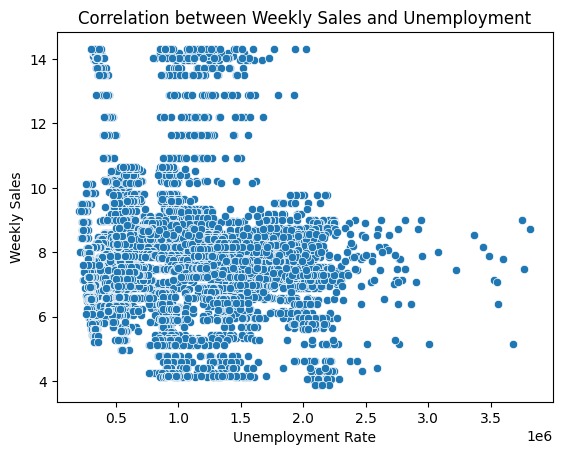

In [123]:
# visulatization of correlation between weekly sales and unemployment
sns.scatterplot(data=df, x='Weekly_Sales', y='Unemployment')
plt.title('Correlation between Weekly Sales and Unemployment')
plt.xlabel('Unemployment Rate')
plt.ylabel('Weekly Sales')
plt.show()

In [124]:
# Reset index to flatten the multi-index
store_corr=df.groupby('Store')[['Weekly_Sales','Unemployment']].corr()
store_corr = store_corr.reset_index()
print(store_corr)

    Store       level_1  Weekly_Sales  Unemployment
0       1  Weekly_Sales      1.000000     -0.097955
1       1  Unemployment     -0.097955      1.000000
2       2  Weekly_Sales      1.000000      0.066325
3       2  Unemployment      0.066325      1.000000
4       3  Weekly_Sales      1.000000     -0.230413
..    ...           ...           ...           ...
85     43  Unemployment     -0.201954      1.000000
86     44  Weekly_Sales      1.000000     -0.780076
87     44  Unemployment     -0.780076      1.000000
88     45  Weekly_Sales      1.000000     -0.004041
89     45  Unemployment     -0.004041      1.000000

[90 rows x 4 columns]


In [125]:
# Filter → we only want the correlation of Weekly_Sales vs Unemployment for each store
store_corr_filtered = store_corr[store_corr['level_1'] == 'Weekly_Sales'][['Store', 'Unemployment']]
#print(store_corr_filtered)
store_corr_filtered = store_corr_filtered.rename(columns={'Unemployment': 'Sales_Unemployment_Correlation'})

print("\nFiltered correlation (Weekly_Sales vs Unemployment per store):")
print(store_corr_filtered)




Filtered correlation (Weekly_Sales vs Unemployment per store):
    Store  Sales_Unemployment_Correlation
0       1                       -0.097955
2       2                        0.066325
4       3                       -0.230413
6       4                       -0.337015
8       5                       -0.207043
10      6                        0.044251
12      7                       -0.165382
14      8                       -0.052580
16      9                       -0.191534
18     10                        0.131908
20     11                       -0.020339
22     12                       -0.009286
24     13                       -0.171633
26     14                        0.210786
28     15                        0.078905
30     16                       -0.070864
32     17                       -0.263600
34     18                        0.139179
36     19                        0.101464
38     20                       -0.095341
40     21                        0.218367
42     22   

In [126]:
# Find top 5 stores most negatively affected (lowest correlation values)
worst_affected_stores = store_corr_filtered.sort_values(by='Sales_Unemployment_Correlation').head(5)
print("\nTop 5 worst affected stores:")
print(worst_affected_stores)




Top 5 worst affected stores:
    Store  Sales_Unemployment_Correlation
74     38                       -0.785290
86     44                       -0.780076
76     39                       -0.384681
82     42                       -0.356355
80     41                       -0.350630


<ipython-input-127-ddffa973a3e6>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Store', y='Sales_Unemployment_Correlation', data=worst_affected_stores,palette=custom_colors)


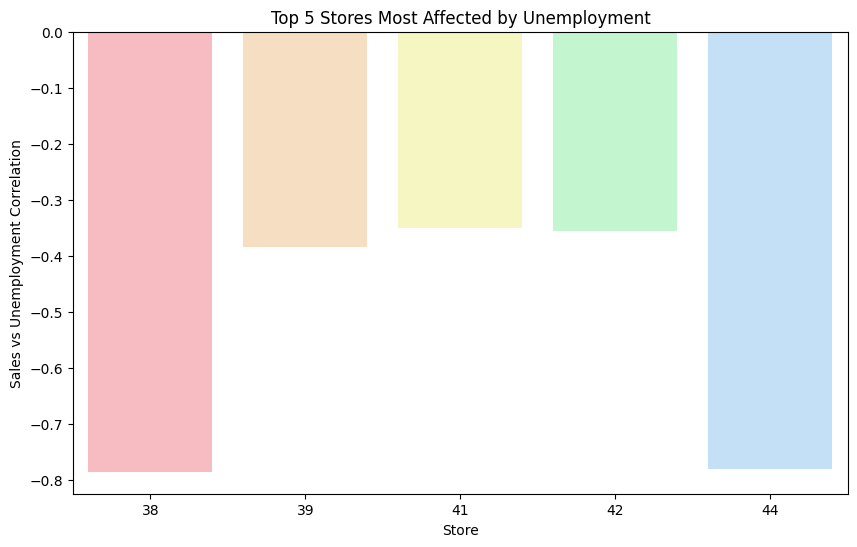

In [127]:
#  Plot
plt.figure(figsize=(10, 6))
custom_colors=['#FFB3BA','#FFDFBA','#FFFFBA','#BAFFC9','#BAE1FF']
sns.barplot(x='Store', y='Sales_Unemployment_Correlation', data=worst_affected_stores,palette=custom_colors)
plt.title('Top 5 Stores Most Affected by Unemployment')
plt.xlabel('Store')
plt.ylabel('Sales vs Unemployment Correlation')
plt.show()

In [128]:
# checking seasonal trend with weakly sales
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [129]:
# Plot total sales per week
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()
print(weekly_sales)

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
                 ...     
2012-09-28    43734899.40
2012-10-05    47566639.31
2012-10-12    46128514.25
2012-10-19    45122410.57
2012-10-26    45544116.29
Name: Weekly_Sales, Length: 143, dtype: float64


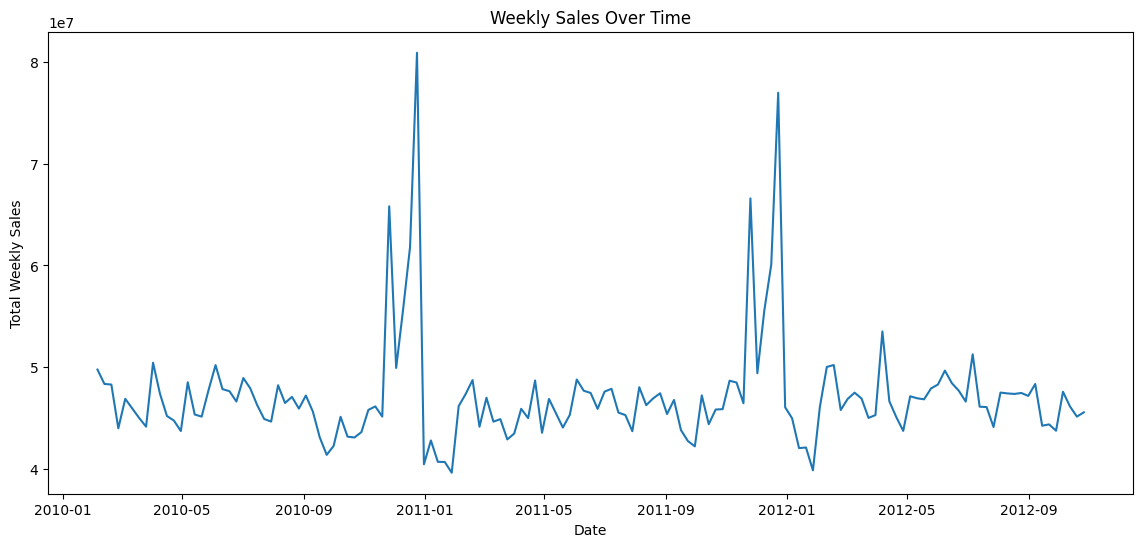

In [130]:
plt.figure(figsize=(14,6))
plt.plot(weekly_sales.index, weekly_sales.values)
plt.title('Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.show()

**The line chart shows that Walmart's weekly sales exhibit a clear seasonal trend. Sales consistently peak during the months of November and December each year, likely due to Thanksgiving, Black Friday, and Christmas shopping periods. Apart from these seasonal peaks, weekly sales remain relatively stable throughout the rest of the year.**

In [131]:
#correlection between sales and temperature
correlation_sales_temperature = df['Weekly_Sales'].corr(df['Temperature'])
print(f"Correlation between Weekly Sales and temperature: {correlation_sales_temperature}")

Correlation between Weekly Sales and temperature: -0.06381001317946956


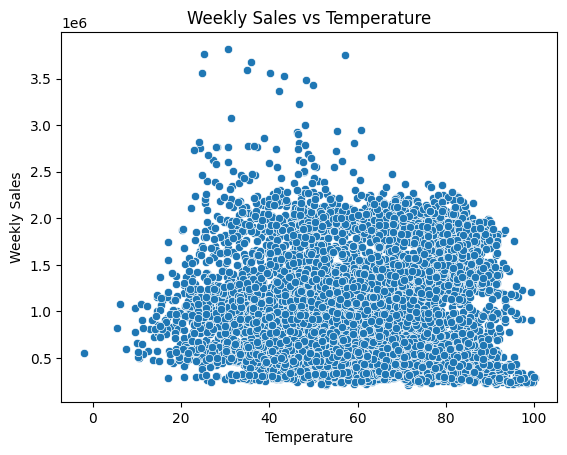

In [132]:
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df)
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.title('Weekly Sales vs Temperature')
plt.show()

The correlation between temperature and weekly sales is -0.06, indicating a very weak negative relationship. This suggests that temperature does not significantly impact weekly sales. Sales remain relatively stable regardless of temperature variations

In [133]:
#correlection between sales and Customer Price Index
correlation_sales_cpi = df['Weekly_Sales'].corr(df['CPI'])
print(f"Correlation between Weekly Sales and Customer Price Index: {correlation_sales_cpi}")

Correlation between Weekly Sales and Customer Price Index: -0.0726341620401763


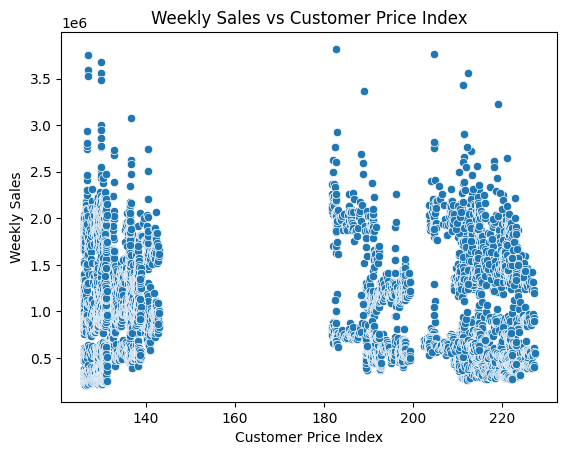

In [134]:
#visulaization of correlation between Sales and Customer Price Index
sns.scatterplot(x='CPI', y='Weekly_Sales', data=df)
plt.xlabel('Customer Price Index')
plt.ylabel('Weekly Sales')
plt.title('Weekly Sales vs Customer Price Index')
plt.show()

In [135]:
# Calculate correlation between Weekly_Sales and CPI for each store
store_cpi_corr = df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['CPI'])).reset_index(name='Sales_CPI_Correlation')

print(store_cpi_corr)

    Store  Sales_CPI_Correlation
0       1               0.225408
1       2              -0.062431
2       3               0.317250
3       4               0.351157
4       5               0.308261
5       6              -0.011357
6       7               0.289044
7       8               0.120255
8       9               0.294805
9      10              -0.115374
10     11               0.069781
11     12               0.084087
12     13               0.163976
13     14              -0.419755
14     15              -0.174467
15     16               0.124285
16     17               0.348571
17     18              -0.193541
18     19              -0.155341
19     20               0.058706
20     21              -0.163649
21     22              -0.038602
22     23               0.084248
23     24              -0.013684
24     25              -0.010914
25     26               0.131980
26     27              -0.213082
27     28              -0.095908
28     29              -0.072530
29     30 

<ipython-input-135-cfd7aa899140>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  store_cpi_corr = df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['CPI'])).reset_index(name='Sales_CPI_Correlation')


<ipython-input-136-5ef12ce7315c>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Store', y='Sales_CPI_Correlation', data=store_cpi_corr_sorted, palette='pastel')


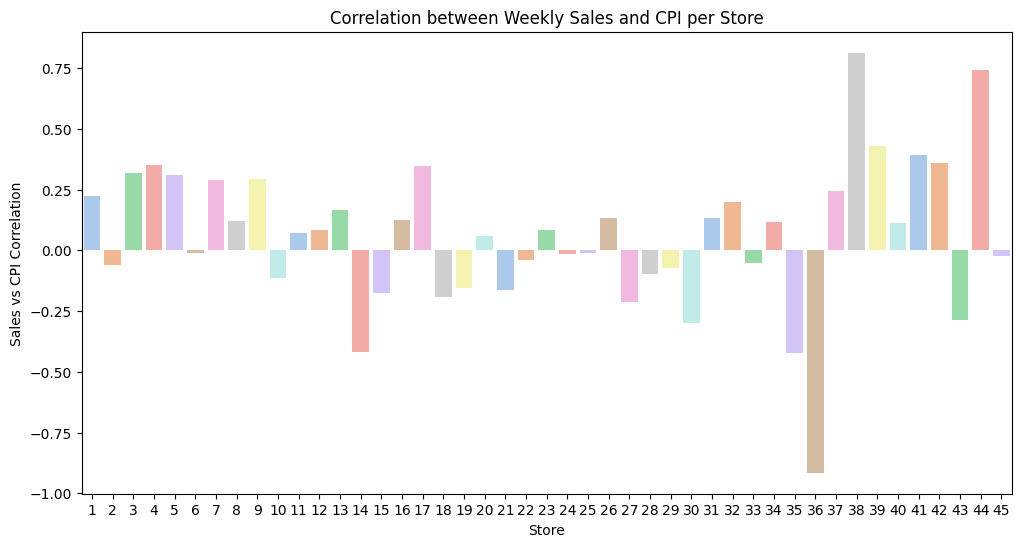

In [136]:
# Sort stores by correlation
store_cpi_corr_sorted = store_cpi_corr.sort_values(by='Sales_CPI_Correlation')

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='Store', y='Sales_CPI_Correlation', data=store_cpi_corr_sorted, palette='pastel')
plt.title('Correlation between Weekly Sales and CPI per Store')
plt.xlabel('Store')
plt.ylabel('Sales vs CPI Correlation')
plt.show()

**The correlation between CPI and weekly sales varies across stores. Most stores show weak correlation, suggesting CPI has limited effect on sales at the store level. However, certain stores (e.g., Store 36 with correlation -0.9) show strong negative correlation, while others (e.g., Store 38 with +0.85) show strong positive correlation, indicating that the impact of CPI is not uniform across all stores and may depend on local factors or customer demographics**

In [137]:
#top stores based on historical data
top_stores_historical = df.groupby('Store')['Weekly_Sales'].sum().reset_index()
top_stores_historical = top_stores_historical.sort_values(by='Weekly_Sales', ascending=False)
print(top_stores_historical)

    Store  Weekly_Sales
19     20  3.013978e+08
3       4  2.995440e+08
13     14  2.889999e+08
12     13  2.865177e+08
1       2  2.753824e+08
9      10  2.716177e+08
26     27  2.538559e+08
5       6  2.237561e+08
0       1  2.224028e+08
38     39  2.074455e+08
18     19  2.066349e+08
30     31  1.996139e+08
22     23  1.987506e+08
23     24  1.940160e+08
10     11  1.939628e+08
27     28  1.892637e+08
40     41  1.813419e+08
31     32  1.668192e+08
17     18  1.551147e+08
21     22  1.470756e+08
11     12  1.442872e+08
25     26  1.434164e+08
33     34  1.382498e+08
39     40  1.378703e+08
34     35  1.315207e+08
7       8  1.299512e+08
16     17  1.277821e+08
44     45  1.123953e+08
20     21  1.081179e+08
24     25  1.010612e+08
42     43  9.056544e+07
14     15  8.913368e+07
6       7  8.159828e+07
41     42  7.956575e+07
8       9  7.778922e+07
28     29  7.714155e+07
15     16  7.425243e+07
36     37  7.420274e+07
29     30  6.271689e+07
2       3  5.758674e+07
37     38  5.515

<ipython-input-138-61e58e44d32d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Store', y='Weekly_Sales', data=top_5_stores, palette='pastel')


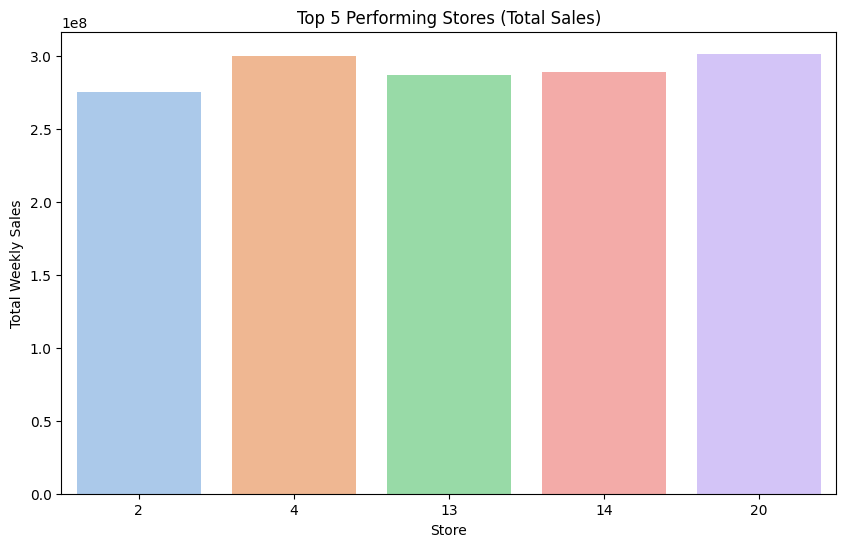

In [138]:
top_5_stores=top_stores_historical.head(5)
plt.figure(figsize=(10,6))
sns.barplot(x='Store', y='Weekly_Sales', data=top_5_stores, palette='pastel')
plt.title('Top 5 Performing Stores (Total Sales)')
plt.xlabel('Store')
plt.ylabel('Total Weekly Sales')
plt.show()

<ipython-input-139-e5fd15808d54>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Store', y='Weekly_Sales', data=worst_5_stores, palette='pastel')


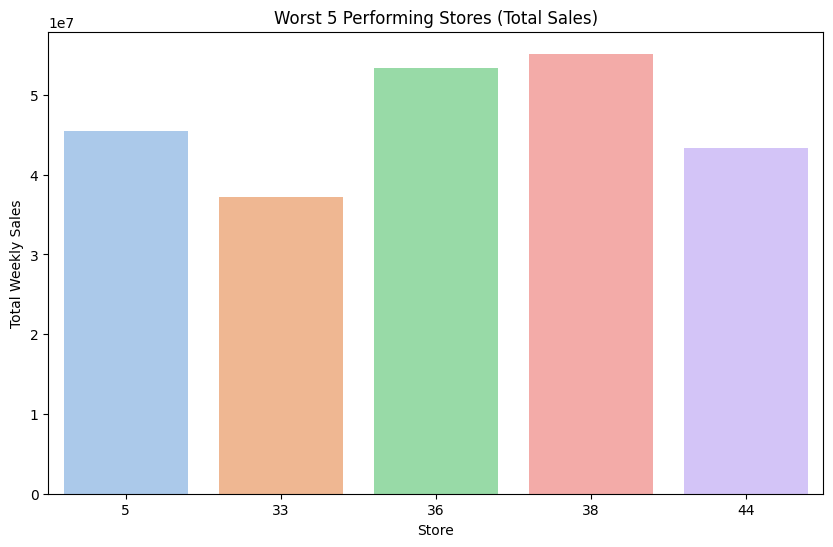

In [139]:
worst_5_stores=top_stores_historical.tail(5)
plt.figure(figsize=(10,6))
sns.barplot(x='Store', y='Weekly_Sales', data=worst_5_stores, palette='pastel')
plt.title('Worst 5 Performing Stores (Total Sales)')
plt.xlabel('Store')
plt.ylabel('Total Weekly Sales')
plt.show()

In [140]:
#difference between best store and worst store in terms of sales
best_store = top_stores_historical.iloc[0]
worst_store = top_stores_historical.iloc[-1]
print(f"Top performing store: Store {best_store['Store']} with total sales {best_store['Weekly_Sales']:,.0f}")
print(f"Worst performing store: Store {worst_store['Store']} with total sales {worst_store['Weekly_Sales']:,.0f}")
sales_difference = best_store['Weekly_Sales'] - worst_store['Weekly_Sales']
print(f"Sales difference between best and worst performing stores: {sales_difference:,.0f}")

Top performing store: Store 20.0 with total sales 301,397,792
Worst performing store: Store 33.0 with total sales 37,160,222
Sales difference between best and worst performing stores: 264,237,570


In [141]:
#predictive modeling techniques to forecast sales for each store for the next
store_ids = df['Store'].unique()
#print(store_ids)

[ 1 10 37 17 30 25 22 23 24 19 21 26 39  8 32 15 34 13 38  9  2 45 20 27
 41  4 31 16 11 36 42  5 43 35 28  6 33 44 18  3 12 29 40  7 14]


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/cmq3w78x.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/7tfc3n0f.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87299', 'data', 'file=/tmp/tmpxis73i44/cmq3w78x.json', 'init=/tmp/tmpxis73i44/7tfc3n0f.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelhe_vxmj3/prophet_model-20250502182951.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:29:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:51 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


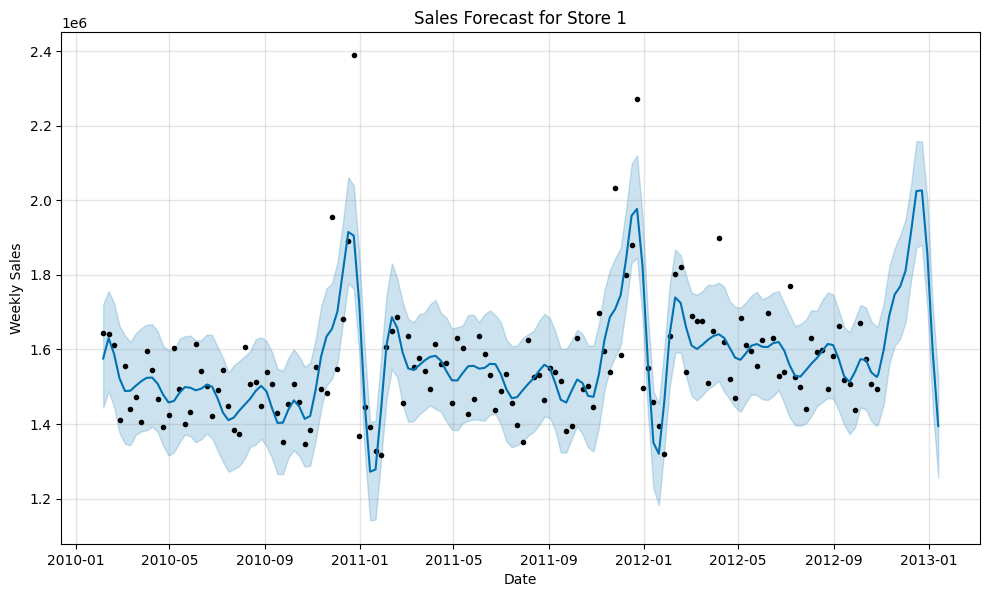

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/4hudwr75.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/08ut5w_v.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=75802', 'data', 'file=/tmp/tmpxis73i44/4hudwr75.json', 'init=/tmp/tmpxis73i44/08ut5w_v.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelau77waxq/prophet_model-20250502182951.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:29:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:51 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


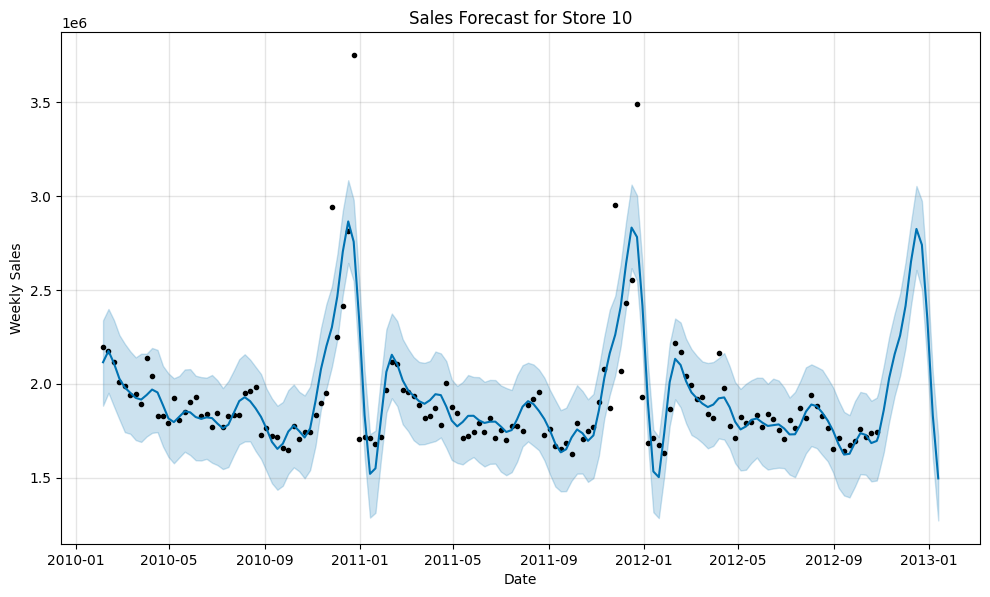

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/76orlage.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/6d979q2m.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=89656', 'data', 'file=/tmp/tmpxis73i44/76orlage.json', 'init=/tmp/tmpxis73i44/6d979q2m.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modeln2wkqvgw/prophet_model-20250502182951.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:29:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:51 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


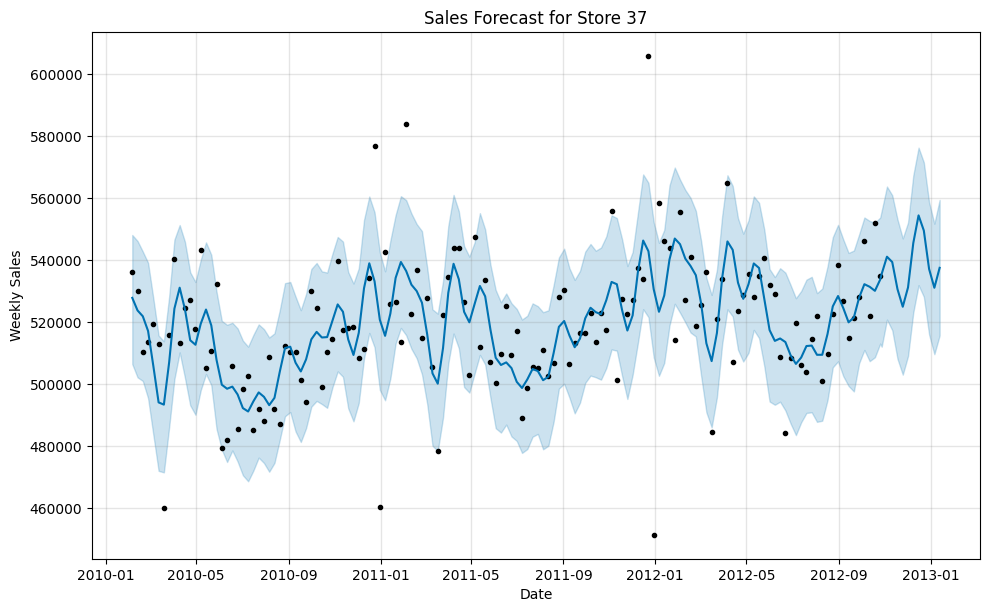

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/ucae6qzg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/2g9t0h0f.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=98637', 'data', 'file=/tmp/tmpxis73i44/ucae6qzg.json', 'init=/tmp/tmpxis73i44/2g9t0h0f.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelpj_43twi/prophet_model-20250502182952.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:29:52 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:52 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


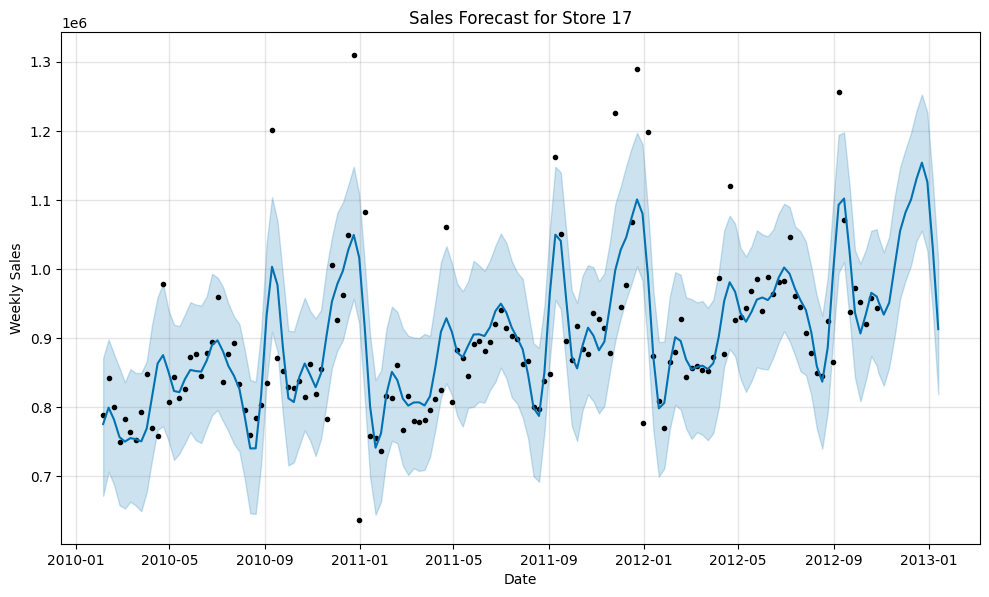

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/_a3215b5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/vvjq0_1c.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=36041', 'data', 'file=/tmp/tmpxis73i44/_a3215b5.json', 'init=/tmp/tmpxis73i44/vvjq0_1c.json', 'output', 'file=/tmp/tmpxis73i44/prophet_model93ce1hht/prophet_model-20250502182953.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:29:53 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


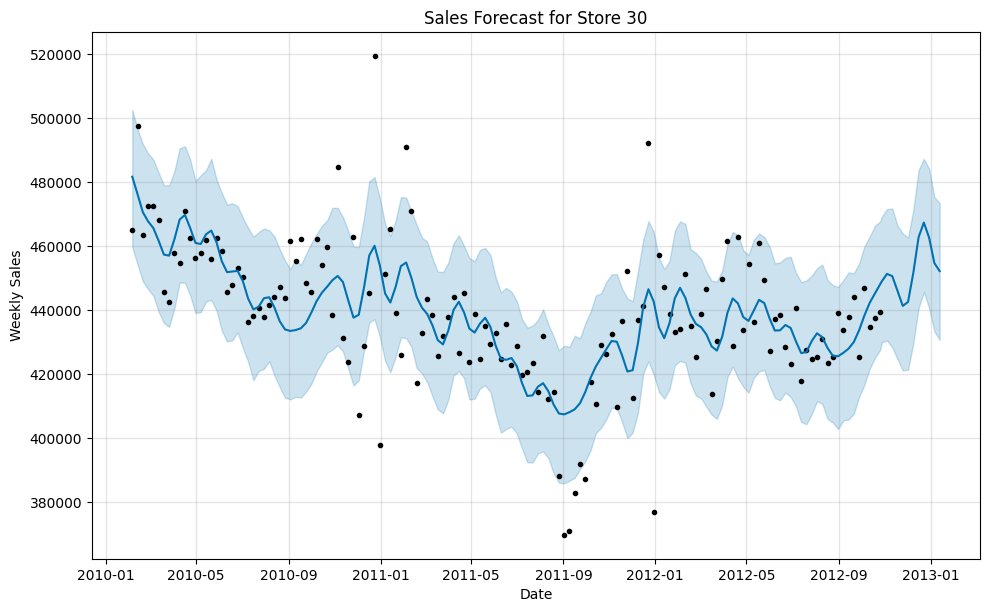

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/ky2wjs3g.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/4vd9g7l_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=13139', 'data', 'file=/tmp/tmpxis73i44/ky2wjs3g.json', 'init=/tmp/tmpxis73i44/4vd9g7l_.json', 'output', 'file=/tmp/tmpxis73i44/prophet_model_7t2_fdz/prophet_model-20250502182954.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:29:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


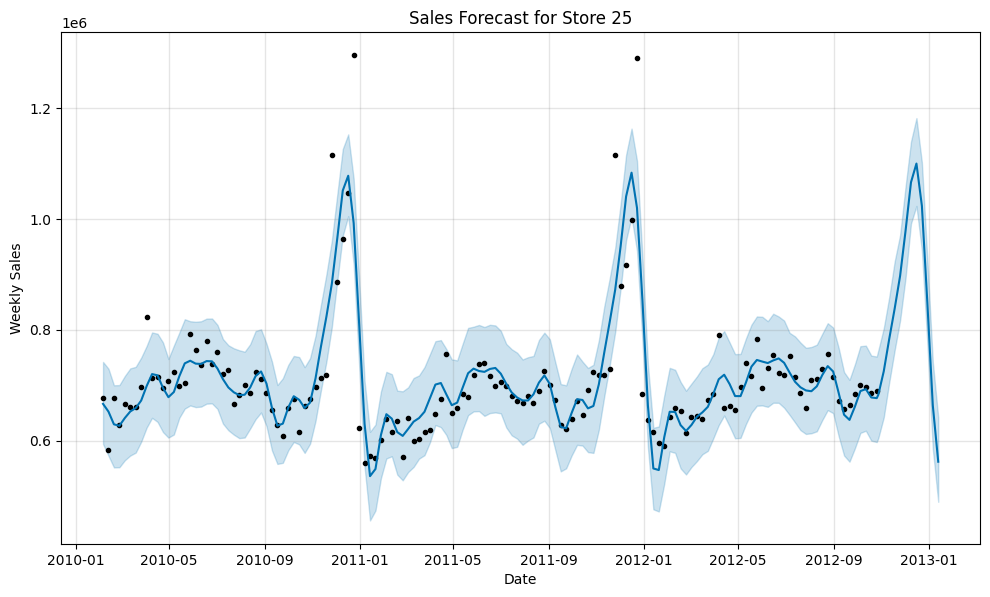

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/d3hdrqnj.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/7563tp92.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=19188', 'data', 'file=/tmp/tmpxis73i44/d3hdrqnj.json', 'init=/tmp/tmpxis73i44/7563tp92.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelwuxf949n/prophet_model-20250502182954.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:29:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:55 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


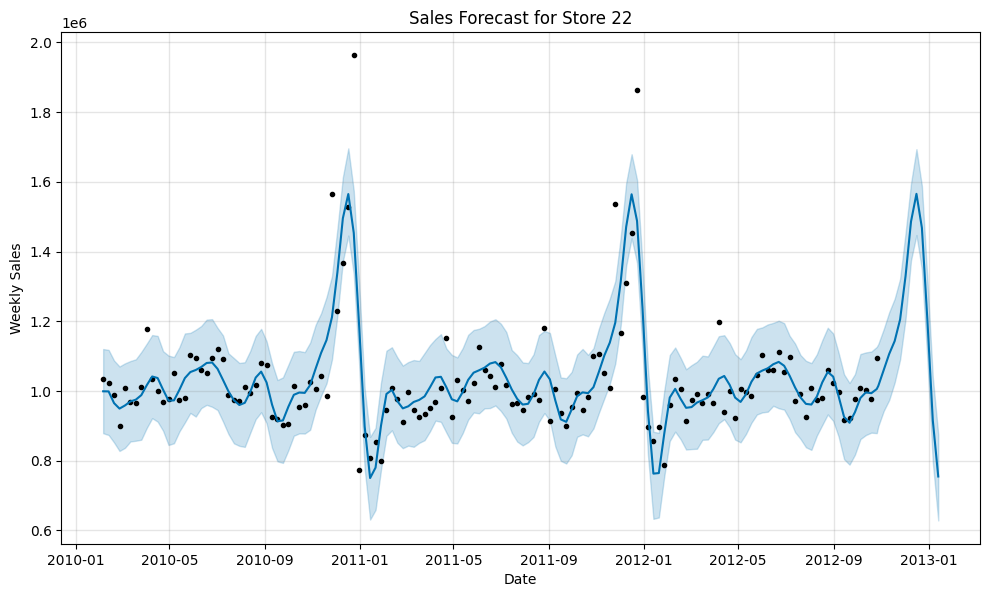

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/uj1__7ih.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/kfbu_xi6.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=80335', 'data', 'file=/tmp/tmpxis73i44/uj1__7ih.json', 'init=/tmp/tmpxis73i44/kfbu_xi6.json', 'output', 'file=/tmp/tmpxis73i44/prophet_model77m8m68s/prophet_model-20250502182956.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:29:56 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:56 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


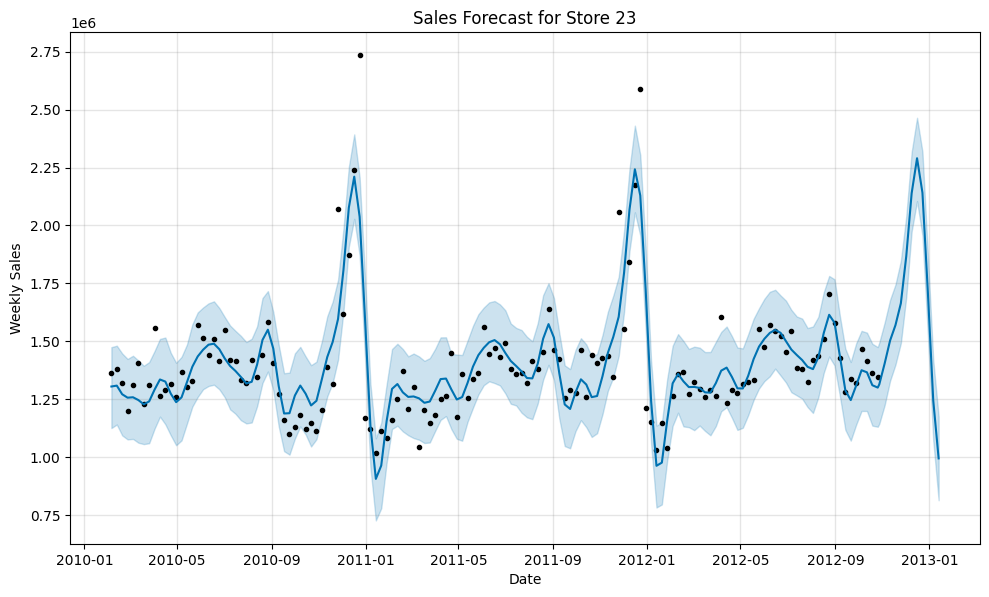

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/6adjgmbv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/x2vov2xz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=99913', 'data', 'file=/tmp/tmpxis73i44/6adjgmbv.json', 'init=/tmp/tmpxis73i44/x2vov2xz.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelwd21snro/prophet_model-20250502182957.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:29:57 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:57 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


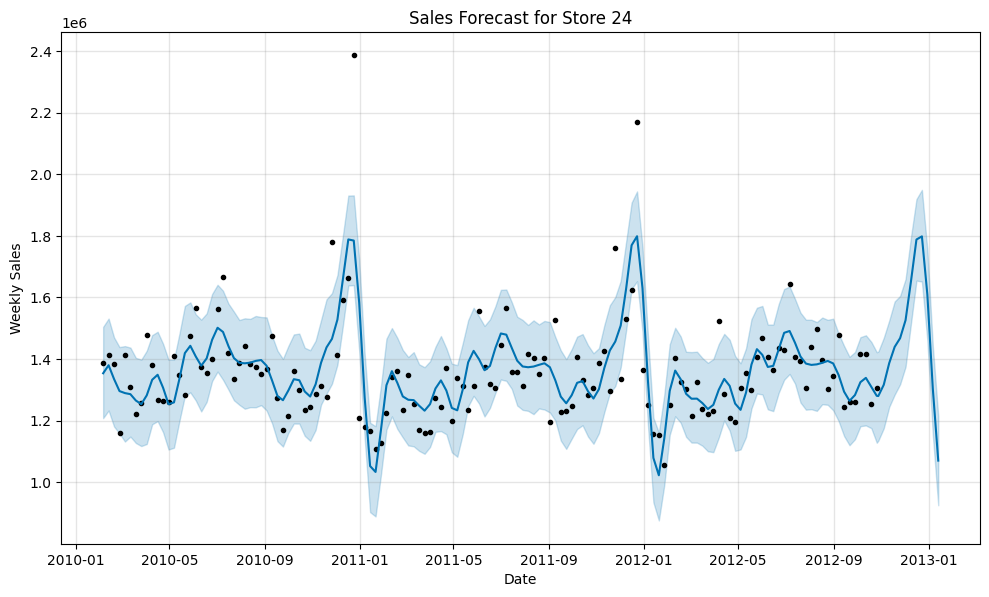

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/i0_a_roa.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/p8ia5o1q.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=38024', 'data', 'file=/tmp/tmpxis73i44/i0_a_roa.json', 'init=/tmp/tmpxis73i44/p8ia5o1q.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelcb8xgktn/prophet_model-20250502182959.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:29:59 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:29:59 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


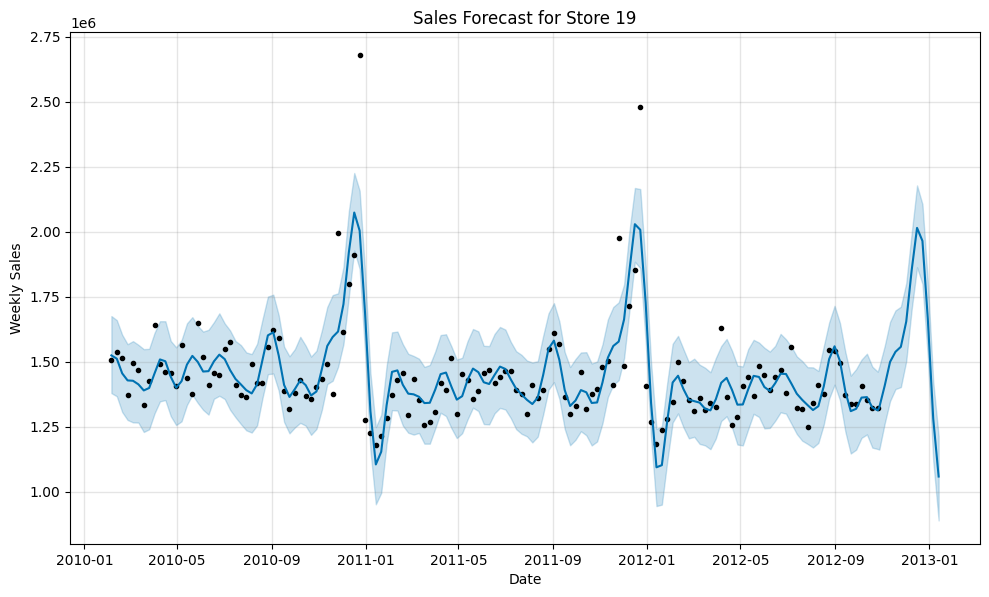

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/8aqpvj3o.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/s9ott8nk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=98088', 'data', 'file=/tmp/tmpxis73i44/8aqpvj3o.json', 'init=/tmp/tmpxis73i44/s9ott8nk.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelkz36tip_/prophet_model-20250502183000.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:00 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:00 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


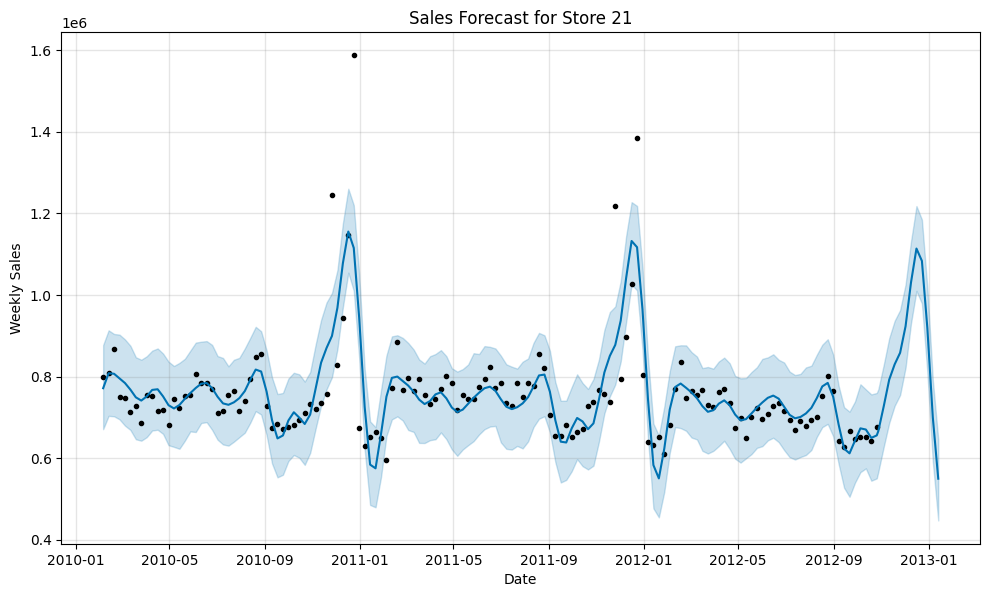

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/etf9hf67.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/o1c_l1l6.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=47518', 'data', 'file=/tmp/tmpxis73i44/etf9hf67.json', 'init=/tmp/tmpxis73i44/o1c_l1l6.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modellr2is_ns/prophet_model-20250502183001.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:02 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


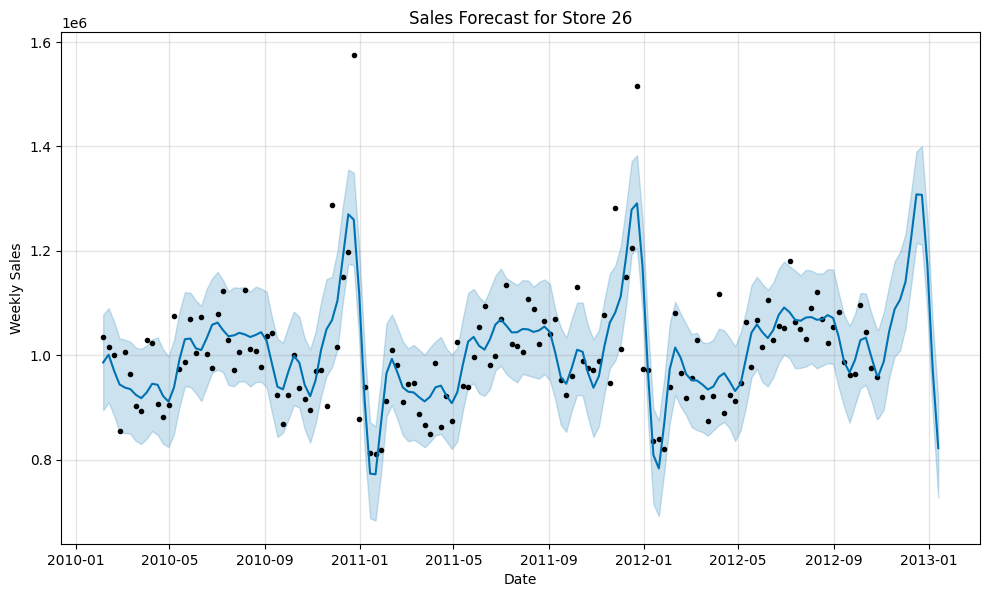

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/kat9z757.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/xg7narf2.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=26546', 'data', 'file=/tmp/tmpxis73i44/kat9z757.json', 'init=/tmp/tmpxis73i44/xg7narf2.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelxjzjkcrz/prophet_model-20250502183002.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:02 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:02 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


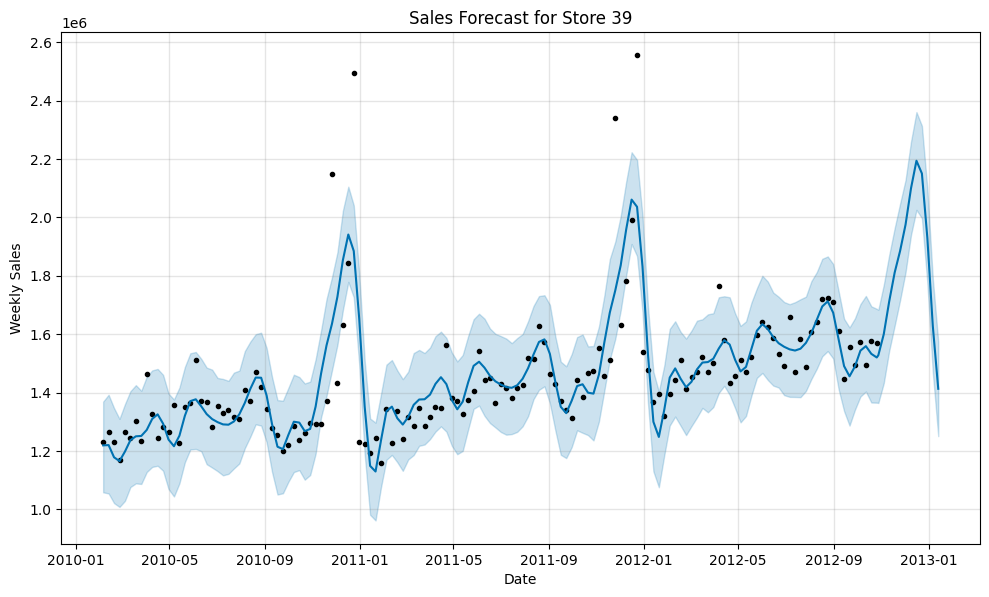

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/lcddtkp6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/s9ski0n5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=29458', 'data', 'file=/tmp/tmpxis73i44/lcddtkp6.json', 'init=/tmp/tmpxis73i44/s9ski0n5.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelzyang7x9/prophet_model-20250502183002.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:02 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:03 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


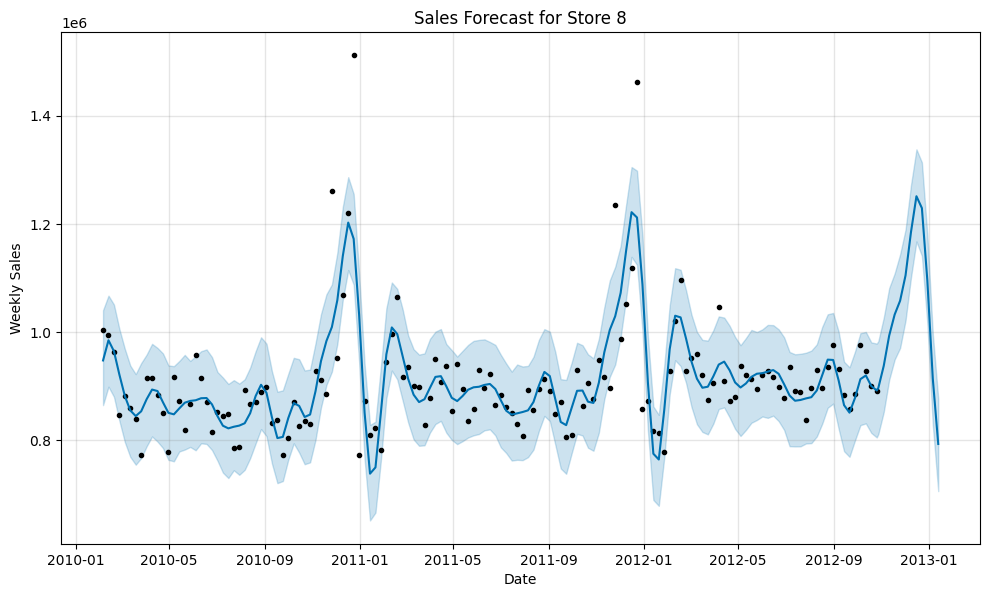

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/3ez014om.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/d40vldfq.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=38506', 'data', 'file=/tmp/tmpxis73i44/3ez014om.json', 'init=/tmp/tmpxis73i44/d40vldfq.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelcovhxb2y/prophet_model-20250502183003.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:03 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:03 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


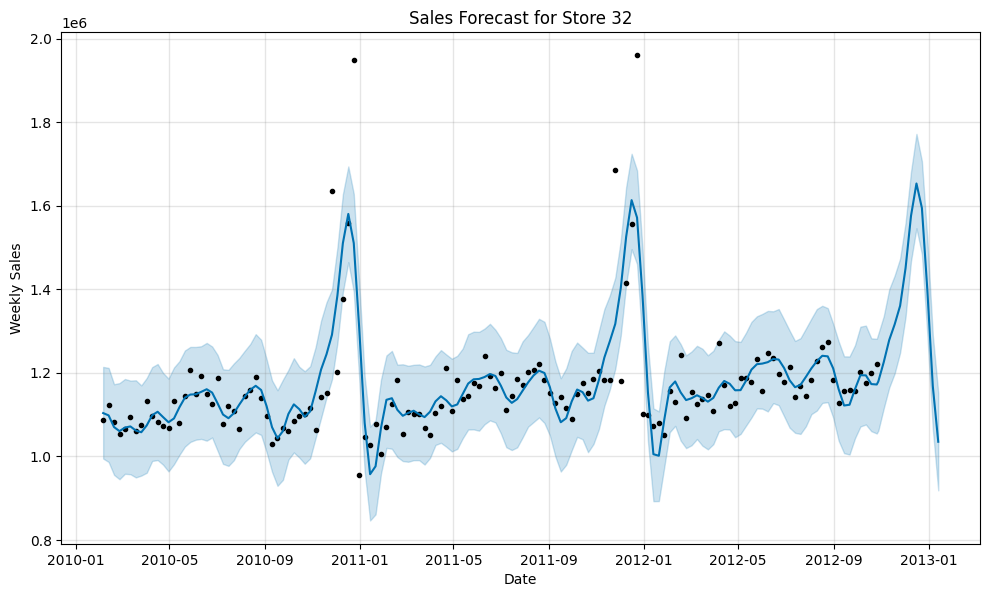

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/u18qzxpx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/ny89w3jy.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=75213', 'data', 'file=/tmp/tmpxis73i44/u18qzxpx.json', 'init=/tmp/tmpxis73i44/ny89w3jy.json', 'output', 'file=/tmp/tmpxis73i44/prophet_model8az2fmg1/prophet_model-20250502183003.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:03 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


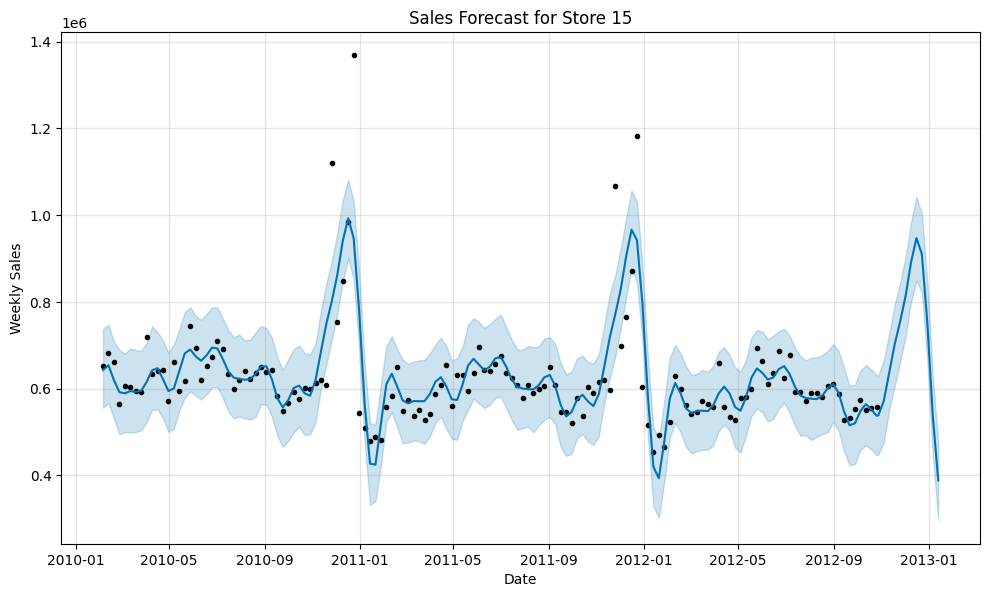

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/42ivu3if.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/9dw36w3e.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=62409', 'data', 'file=/tmp/tmpxis73i44/42ivu3if.json', 'init=/tmp/tmpxis73i44/9dw36w3e.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelt_i48ur6/prophet_model-20250502183004.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:04 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


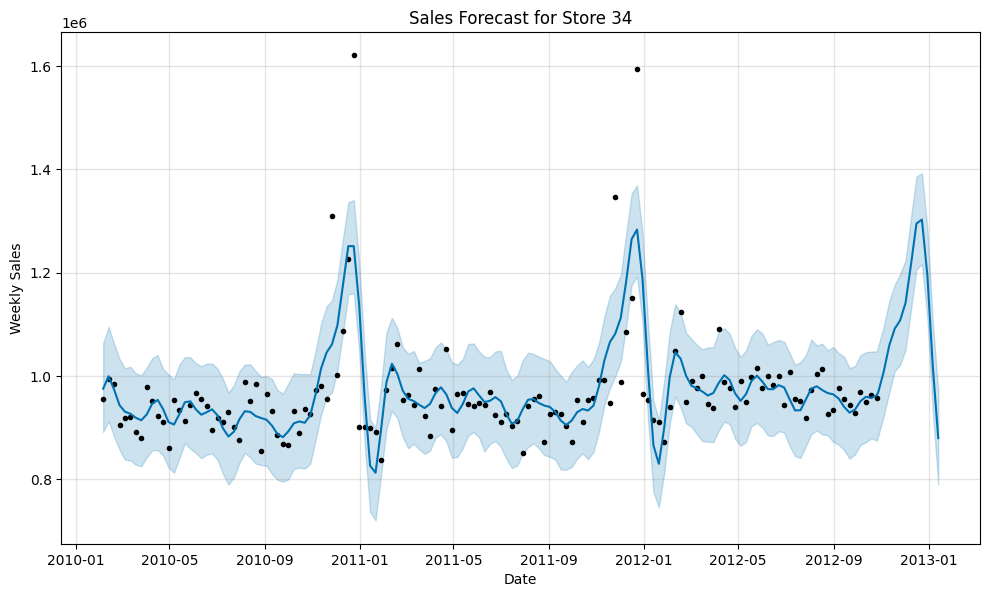

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/c3urrlnb.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/_gh3t0dx.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=16753', 'data', 'file=/tmp/tmpxis73i44/c3urrlnb.json', 'init=/tmp/tmpxis73i44/_gh3t0dx.json', 'output', 'file=/tmp/tmpxis73i44/prophet_models_g3bwx9/prophet_model-20250502183005.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:05 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


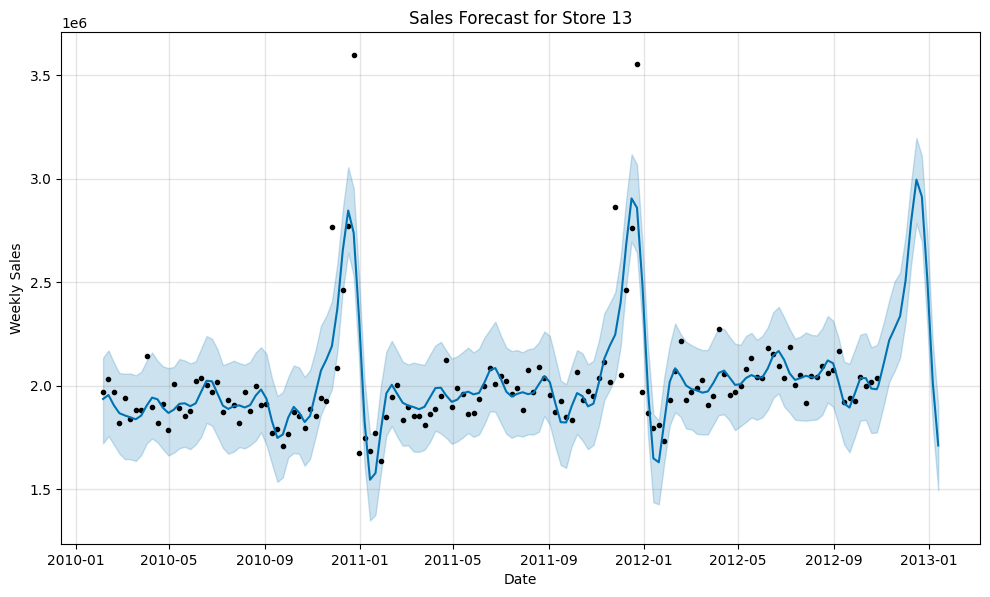

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/myrm2jgi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/hw6aoxgj.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=72265', 'data', 'file=/tmp/tmpxis73i44/myrm2jgi.json', 'init=/tmp/tmpxis73i44/hw6aoxgj.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modeldarzkuod/prophet_model-20250502183005.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:05 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


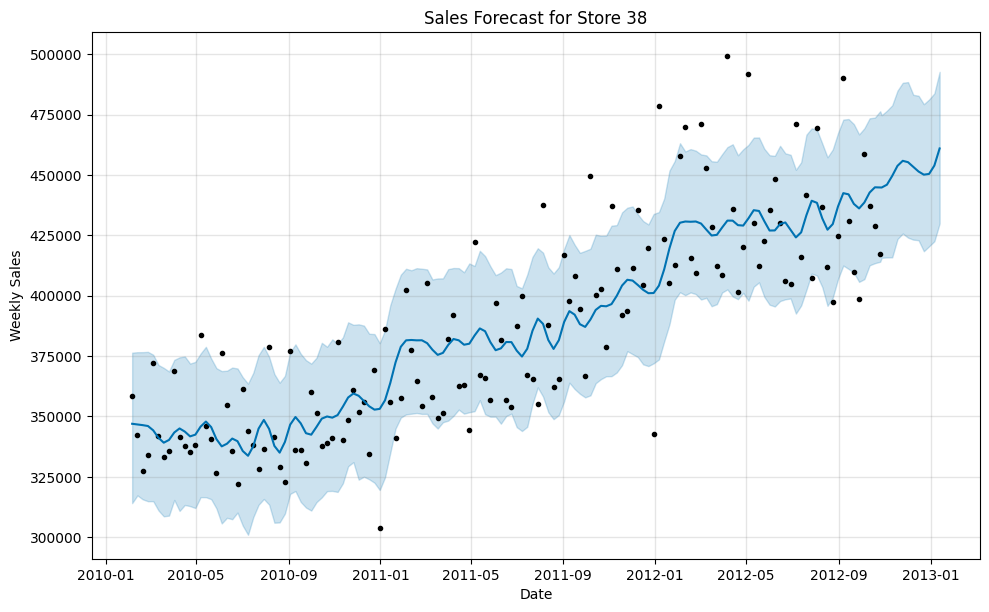

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/g8n_eyr3.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/t4716djr.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=28127', 'data', 'file=/tmp/tmpxis73i44/g8n_eyr3.json', 'init=/tmp/tmpxis73i44/t4716djr.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modellsfkq1cn/prophet_model-20250502183006.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


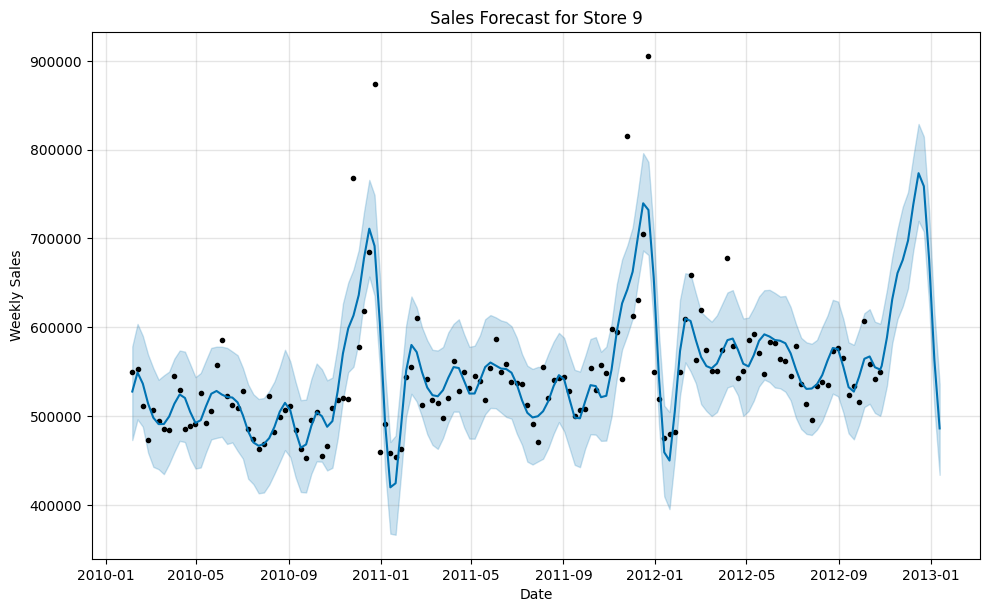

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/v6jp0yjw.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/t_2jr20h.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=59811', 'data', 'file=/tmp/tmpxis73i44/v6jp0yjw.json', 'init=/tmp/tmpxis73i44/t_2jr20h.json', 'output', 'file=/tmp/tmpxis73i44/prophet_model6xdnbpj1/prophet_model-20250502183006.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


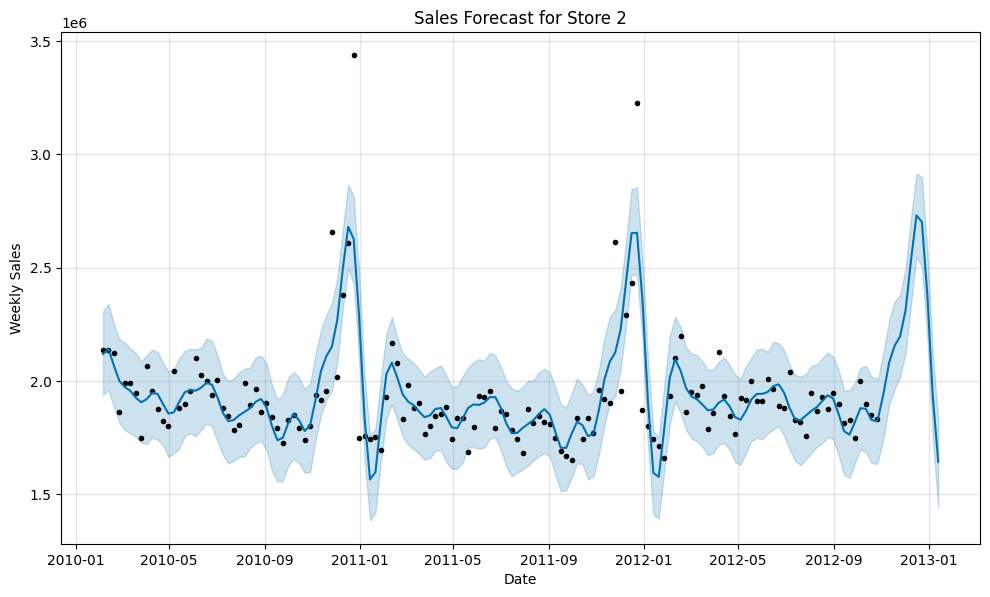

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/ztlvwum_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/m9p1rlj9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=53483', 'data', 'file=/tmp/tmpxis73i44/ztlvwum_.json', 'init=/tmp/tmpxis73i44/m9p1rlj9.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelk9x1y17w/prophet_model-20250502183007.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:07 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


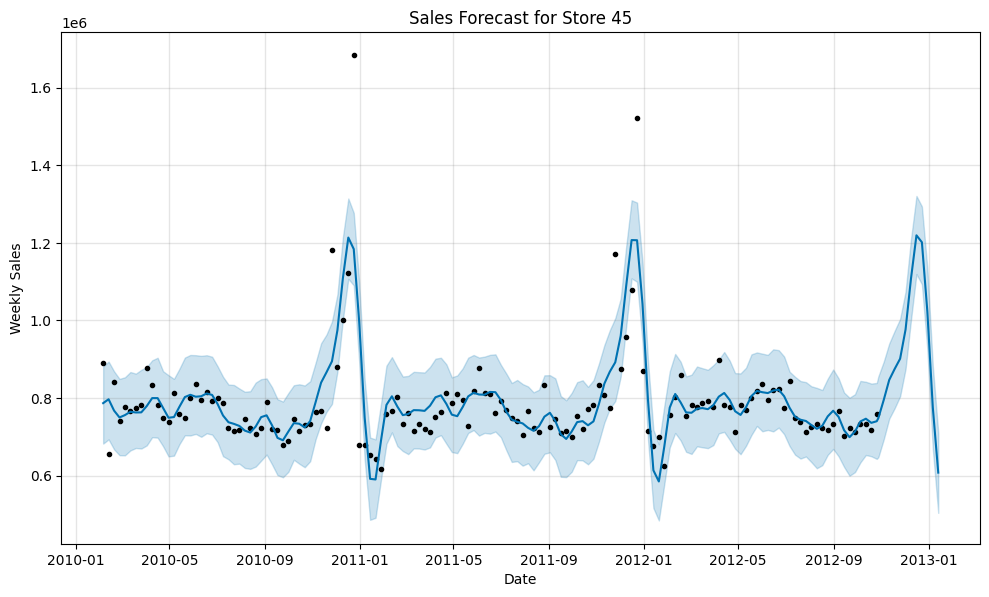

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/uteukguk.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/fkq4cvhx.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=27463', 'data', 'file=/tmp/tmpxis73i44/uteukguk.json', 'init=/tmp/tmpxis73i44/fkq4cvhx.json', 'output', 'file=/tmp/tmpxis73i44/prophet_model8_srb7sn/prophet_model-20250502183007.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:07 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


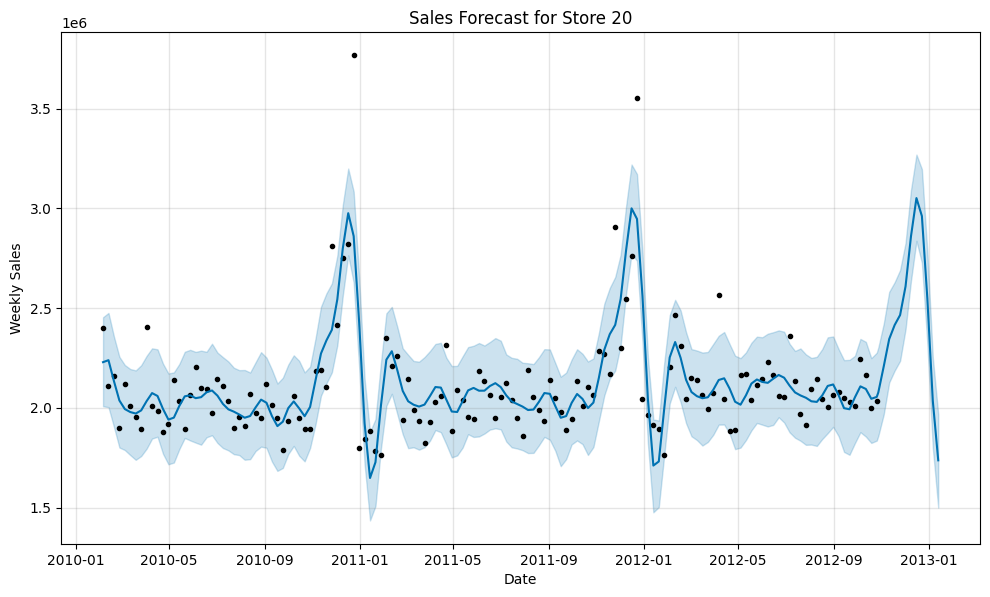

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/4h76dg58.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/j5k0ser2.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=33716', 'data', 'file=/tmp/tmpxis73i44/4h76dg58.json', 'init=/tmp/tmpxis73i44/j5k0ser2.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelc_k6aqzg/prophet_model-20250502183008.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:08 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


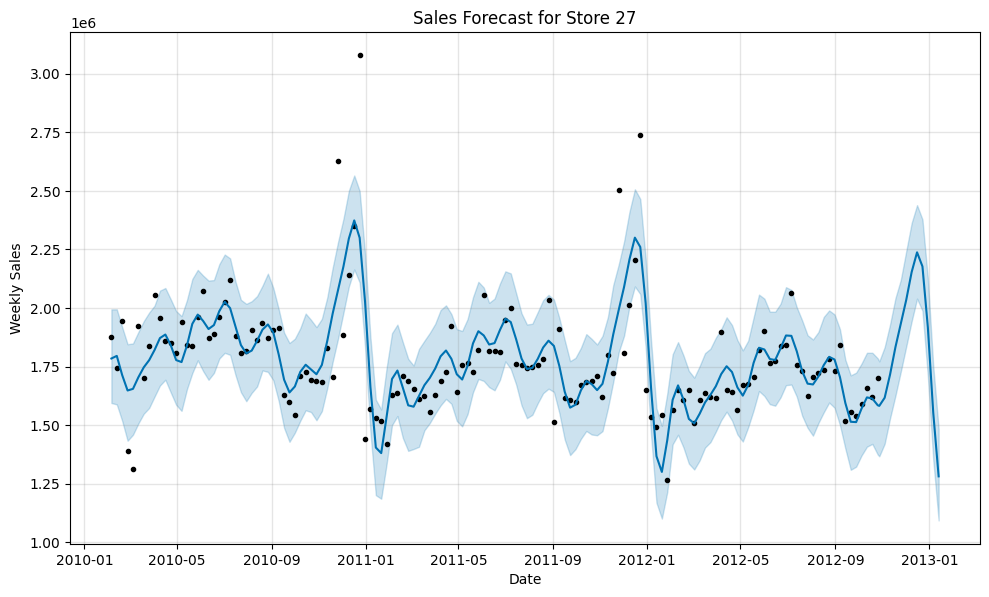

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/ezm7_q06.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/cp903lbz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=42647', 'data', 'file=/tmp/tmpxis73i44/ezm7_q06.json', 'init=/tmp/tmpxis73i44/cp903lbz.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelpxrvr9ot/prophet_model-20250502183009.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:09 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:09 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


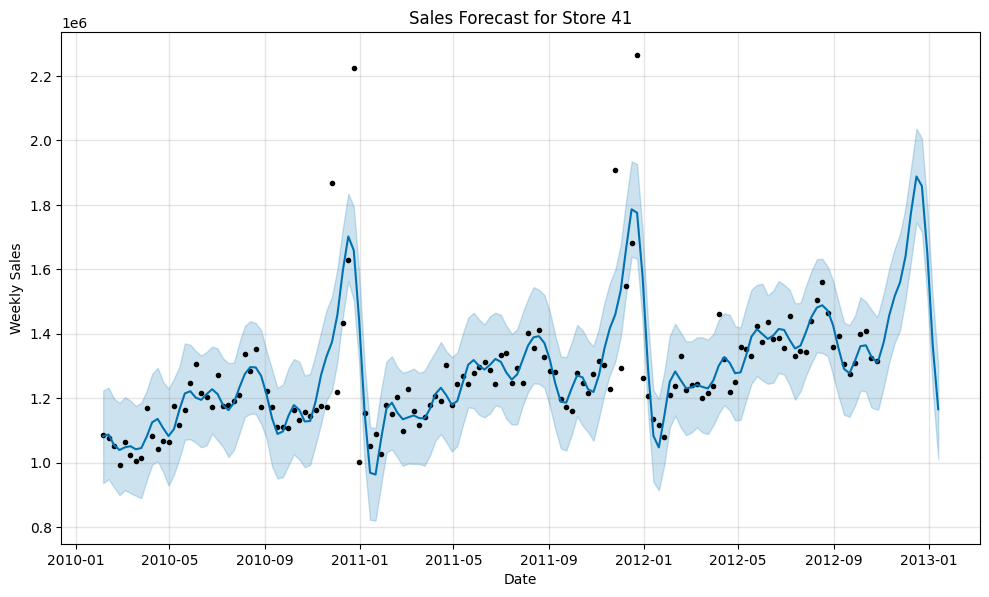

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/e3drolmd.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/tu5ioluh.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=63088', 'data', 'file=/tmp/tmpxis73i44/e3drolmd.json', 'init=/tmp/tmpxis73i44/tu5ioluh.json', 'output', 'file=/tmp/tmpxis73i44/prophet_model0ch1t48g/prophet_model-20250502183009.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:09 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:09 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


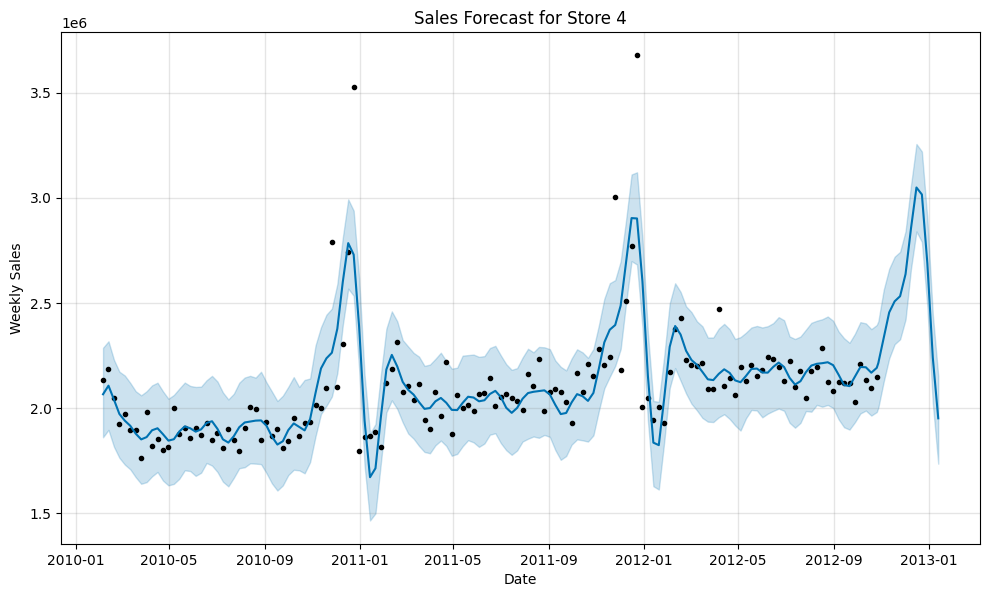

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/eh_7swck.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/om8hraeg.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=77800', 'data', 'file=/tmp/tmpxis73i44/eh_7swck.json', 'init=/tmp/tmpxis73i44/om8hraeg.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modellwp5tj4s/prophet_model-20250502183010.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:10 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:10 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


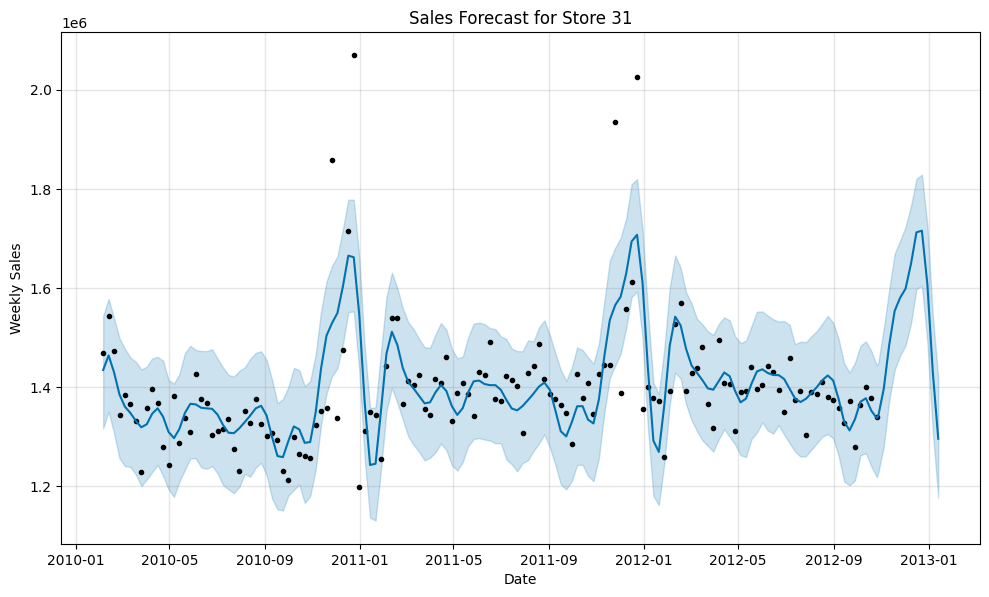

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/dd4bvped.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/yrfy2_xq.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=76212', 'data', 'file=/tmp/tmpxis73i44/dd4bvped.json', 'init=/tmp/tmpxis73i44/yrfy2_xq.json', 'output', 'file=/tmp/tmpxis73i44/prophet_model5rntq7y5/prophet_model-20250502183011.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:11 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


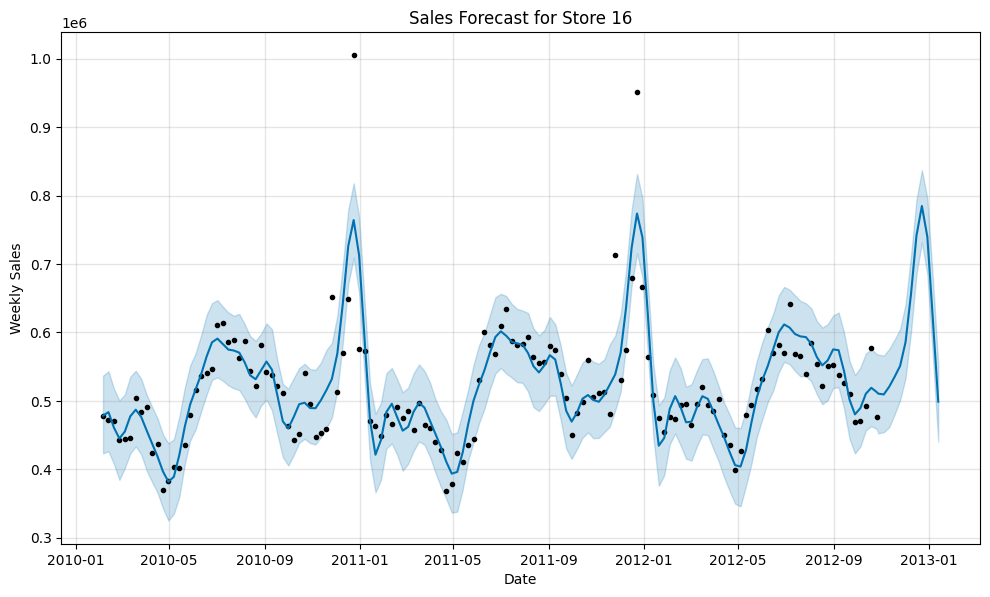

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/yxaez_zk.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/m8o43euc.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=96475', 'data', 'file=/tmp/tmpxis73i44/yxaez_zk.json', 'init=/tmp/tmpxis73i44/m8o43euc.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelyjpevczq/prophet_model-20250502183011.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:11 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


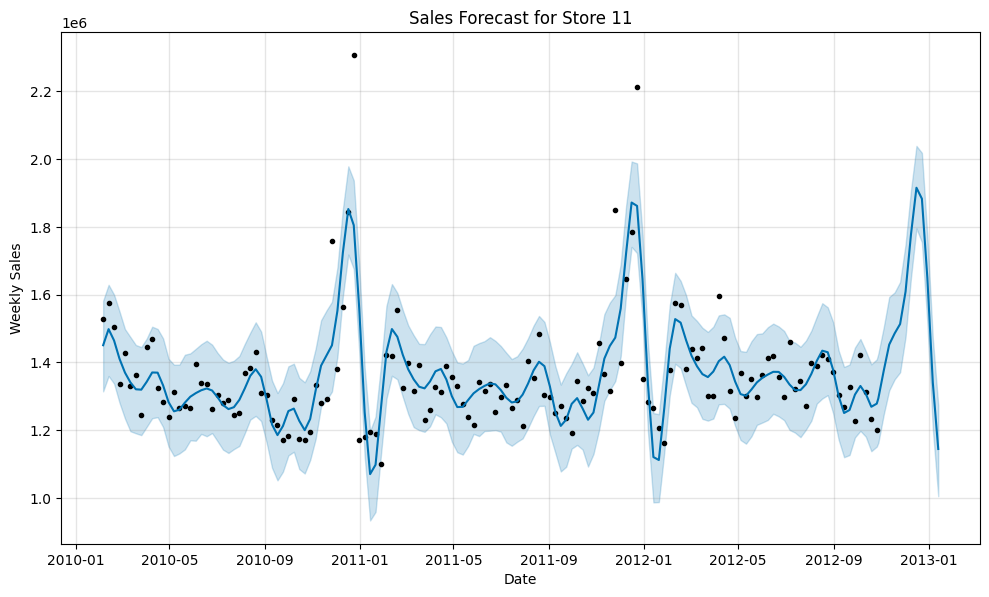

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/w0kvbu7c.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/20r9dlg8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=2347', 'data', 'file=/tmp/tmpxis73i44/w0kvbu7c.json', 'init=/tmp/tmpxis73i44/20r9dlg8.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelojdmuryy/prophet_model-20250502183012.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:12 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:12 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


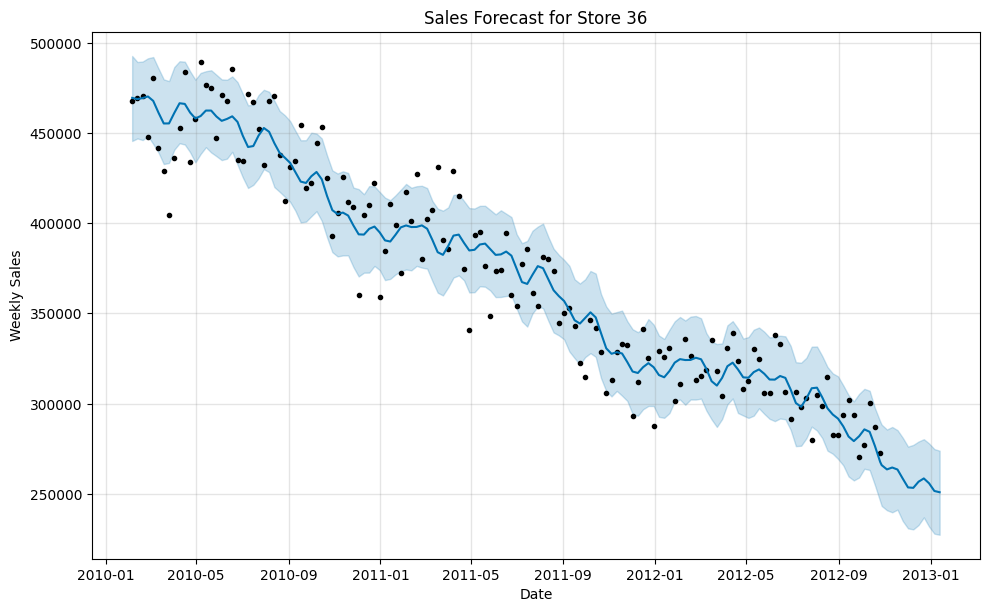

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/u1ez73n8.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/oq763fw_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=68515', 'data', 'file=/tmp/tmpxis73i44/u1ez73n8.json', 'init=/tmp/tmpxis73i44/oq763fw_.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelx63ocguw/prophet_model-20250502183013.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:13 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


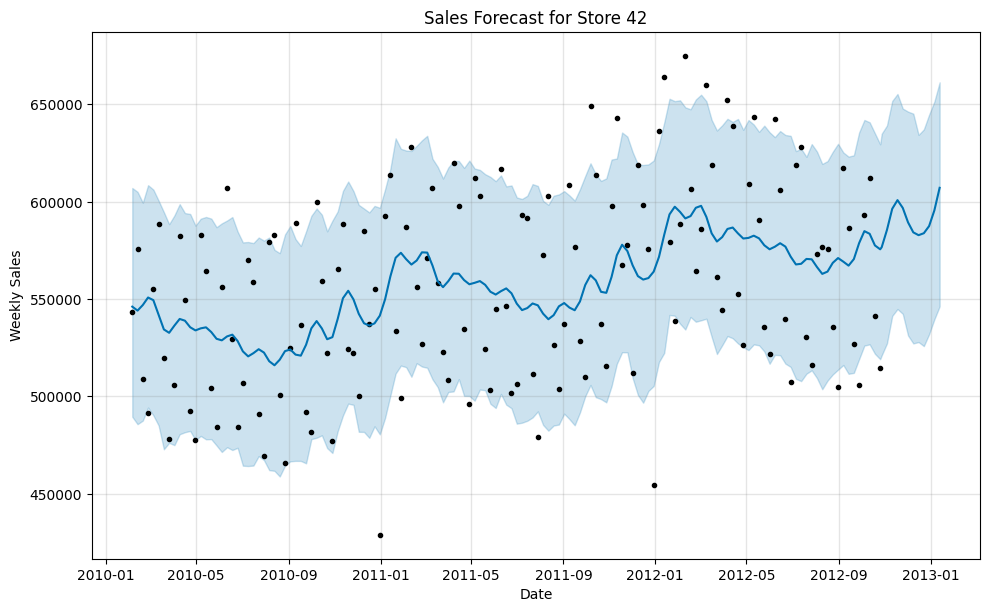

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/a91qw725.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/72sg_8r2.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24310', 'data', 'file=/tmp/tmpxis73i44/a91qw725.json', 'init=/tmp/tmpxis73i44/72sg_8r2.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modellwpx1nj1/prophet_model-20250502183013.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:13 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


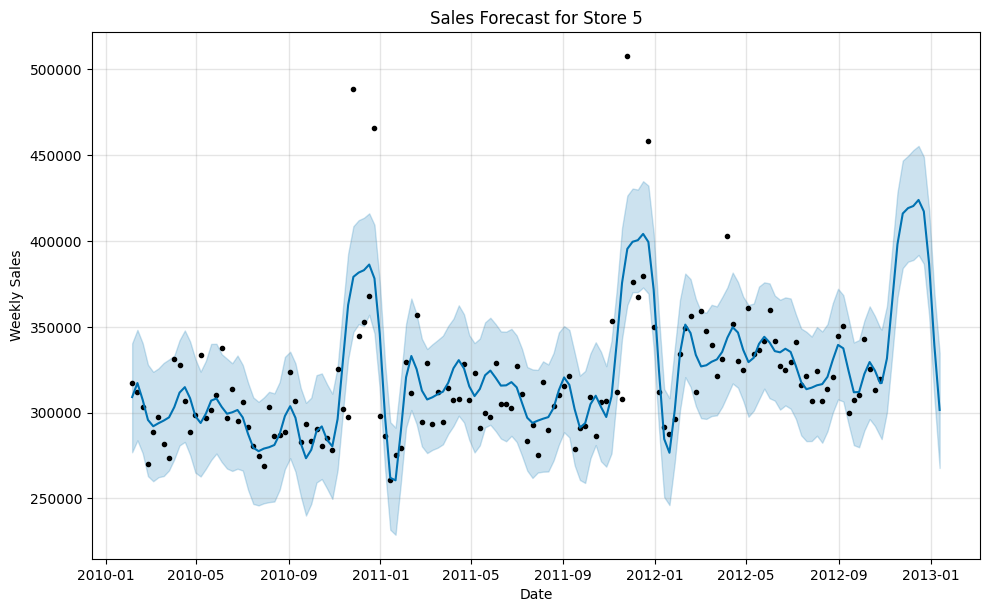

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/gz595zf0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/l4mffxl1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=2187', 'data', 'file=/tmp/tmpxis73i44/gz595zf0.json', 'init=/tmp/tmpxis73i44/l4mffxl1.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelxxt25a2o/prophet_model-20250502183014.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


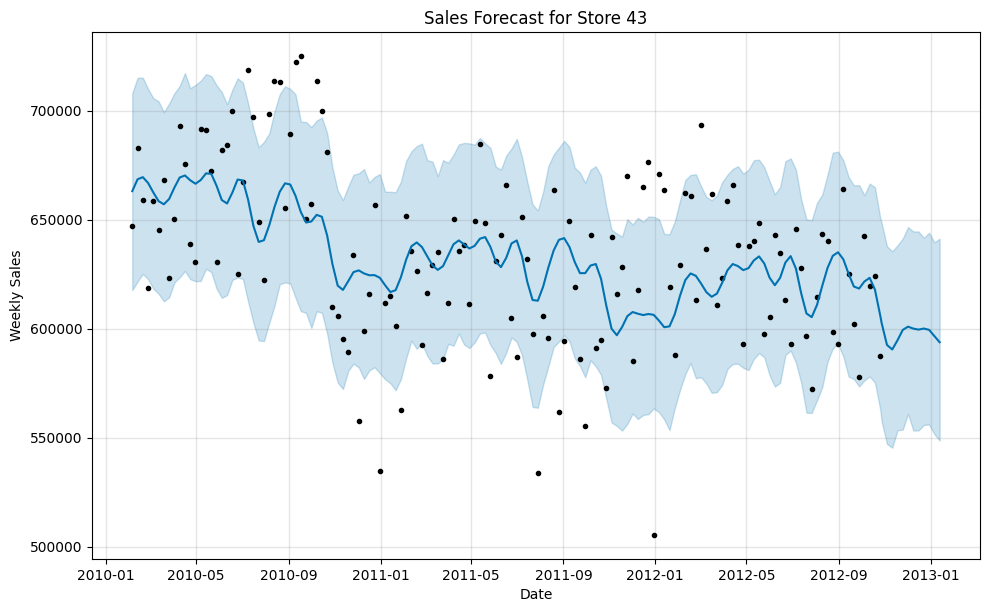

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/q71syxko.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/x51jyr2s.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=90896', 'data', 'file=/tmp/tmpxis73i44/q71syxko.json', 'init=/tmp/tmpxis73i44/x51jyr2s.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelrwm_h8la/prophet_model-20250502183014.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


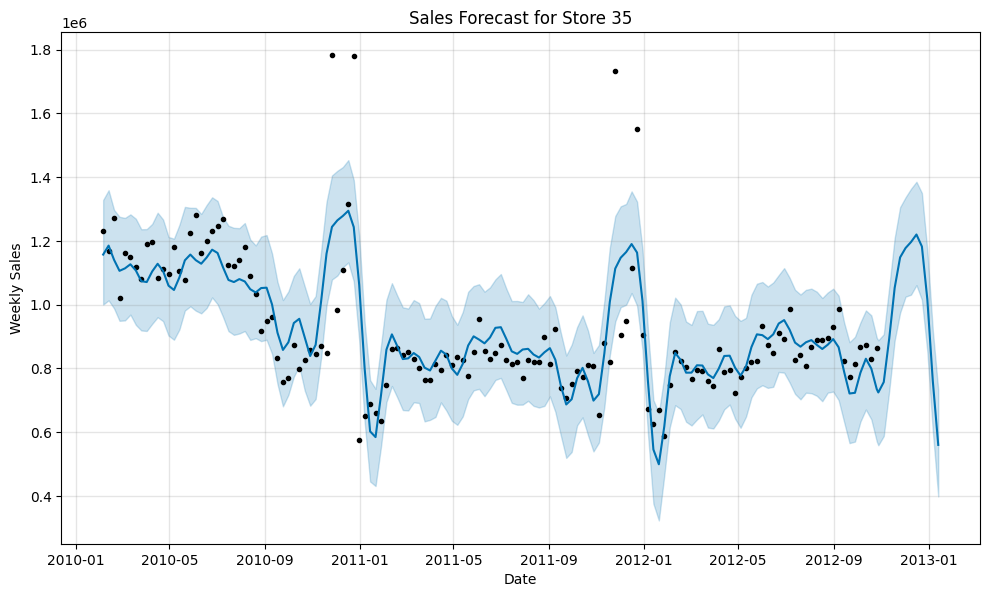

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/k4q9h2g1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/nx3pc4ra.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=74384', 'data', 'file=/tmp/tmpxis73i44/k4q9h2g1.json', 'init=/tmp/tmpxis73i44/nx3pc4ra.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modely9mhuhe4/prophet_model-20250502183015.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:15 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:15 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


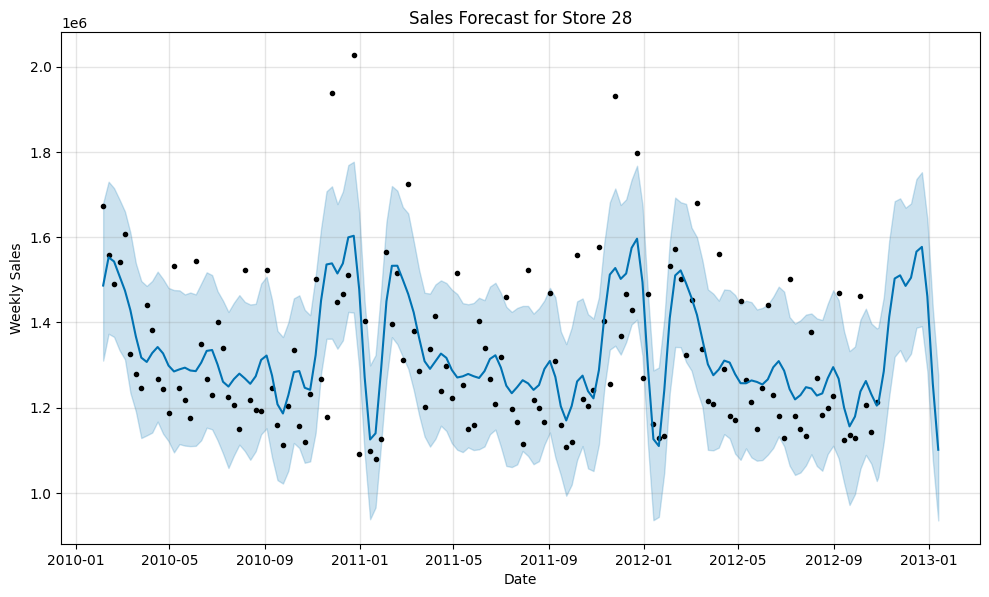

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/gf10yfdo.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/cjvvn6wt.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=63383', 'data', 'file=/tmp/tmpxis73i44/gf10yfdo.json', 'init=/tmp/tmpxis73i44/cjvvn6wt.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelgd0xvvxb/prophet_model-20250502183016.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:16 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:16 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


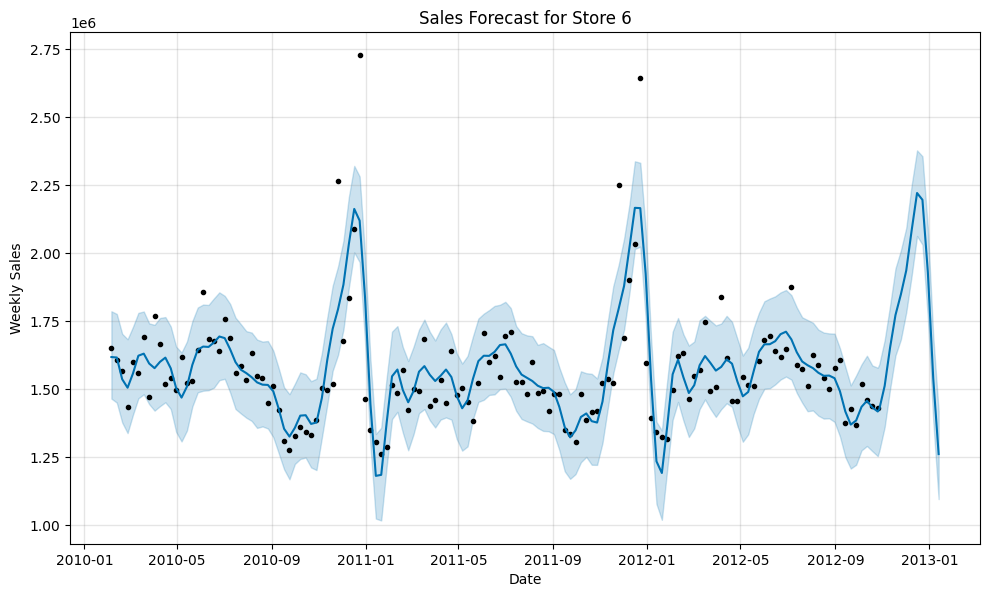

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/8yw9g42x.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/39gpweqs.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=6483', 'data', 'file=/tmp/tmpxis73i44/8yw9g42x.json', 'init=/tmp/tmpxis73i44/39gpweqs.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelqi29lmu6/prophet_model-20250502183016.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:16 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:16 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


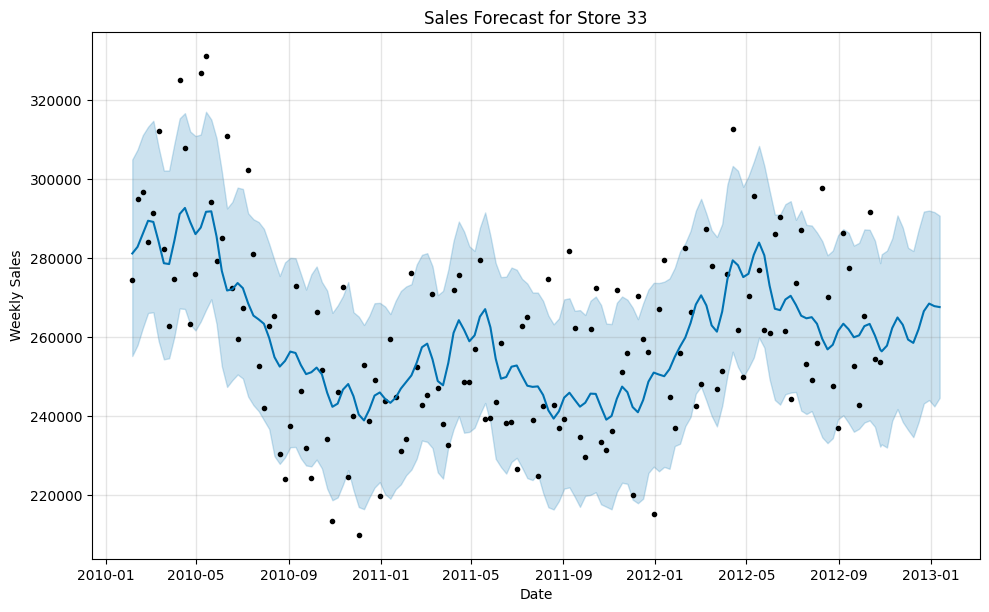

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/4y2ukfk4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/0mn_yopn.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=38225', 'data', 'file=/tmp/tmpxis73i44/4y2ukfk4.json', 'init=/tmp/tmpxis73i44/0mn_yopn.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelxmbi8u97/prophet_model-20250502183017.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:17 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:17 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


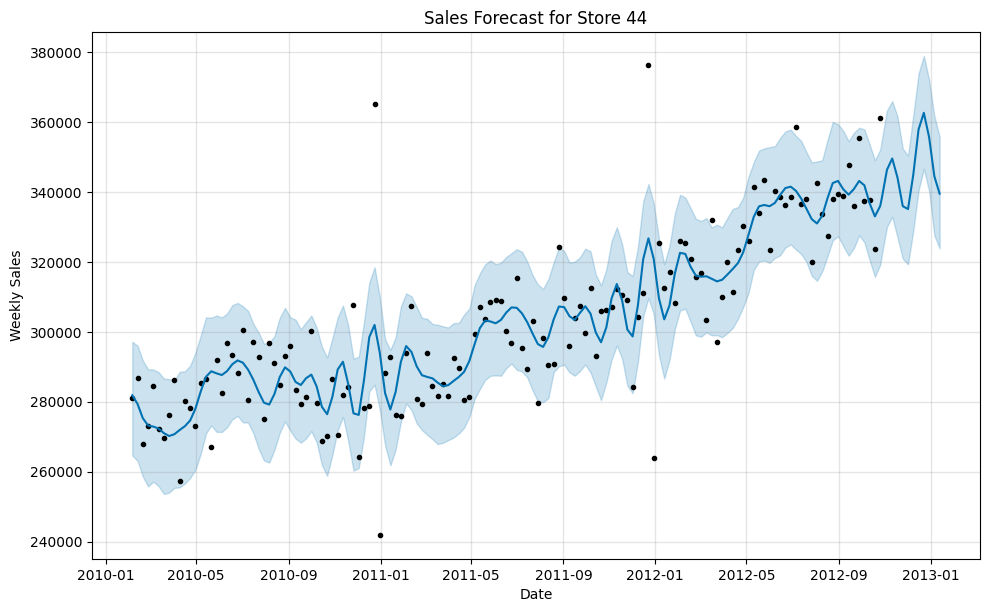

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/h_dp8skh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/f9m1srqx.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=96338', 'data', 'file=/tmp/tmpxis73i44/h_dp8skh.json', 'init=/tmp/tmpxis73i44/f9m1srqx.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelydciqw9z/prophet_model-20250502183017.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:17 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


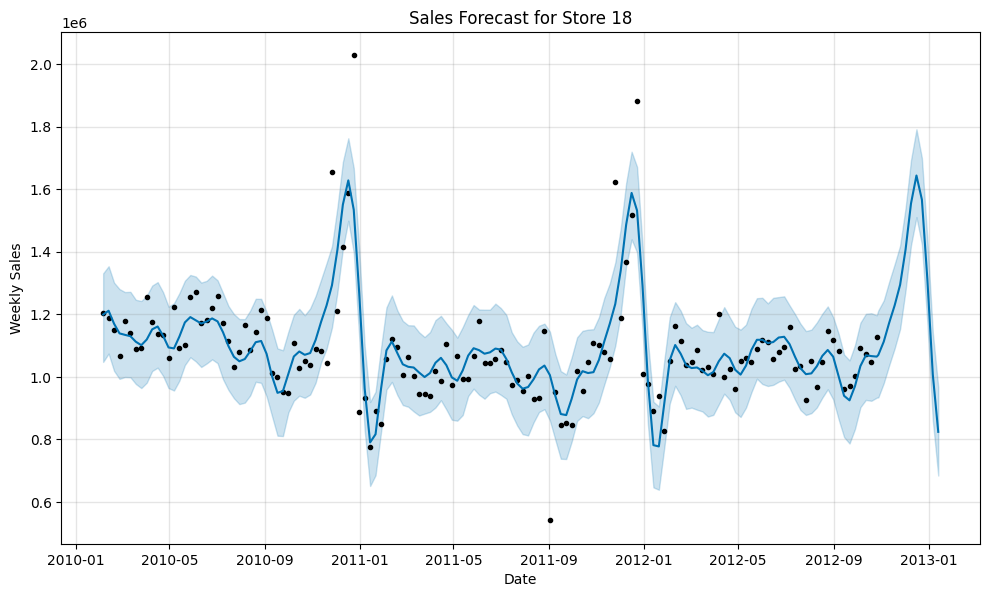

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/xwu_273g.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/_gqaf0m_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=91695', 'data', 'file=/tmp/tmpxis73i44/xwu_273g.json', 'init=/tmp/tmpxis73i44/_gqaf0m_.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelpn_tkv7v/prophet_model-20250502183018.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


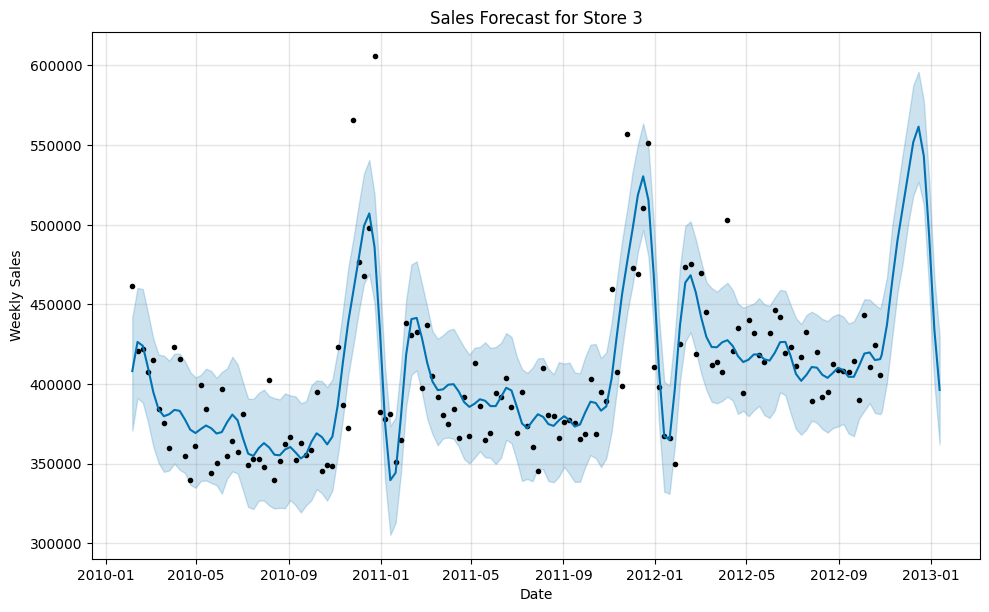

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/m9odc2uh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/3_w2lwcb.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=16752', 'data', 'file=/tmp/tmpxis73i44/m9odc2uh.json', 'init=/tmp/tmpxis73i44/3_w2lwcb.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelisygwci3/prophet_model-20250502183019.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


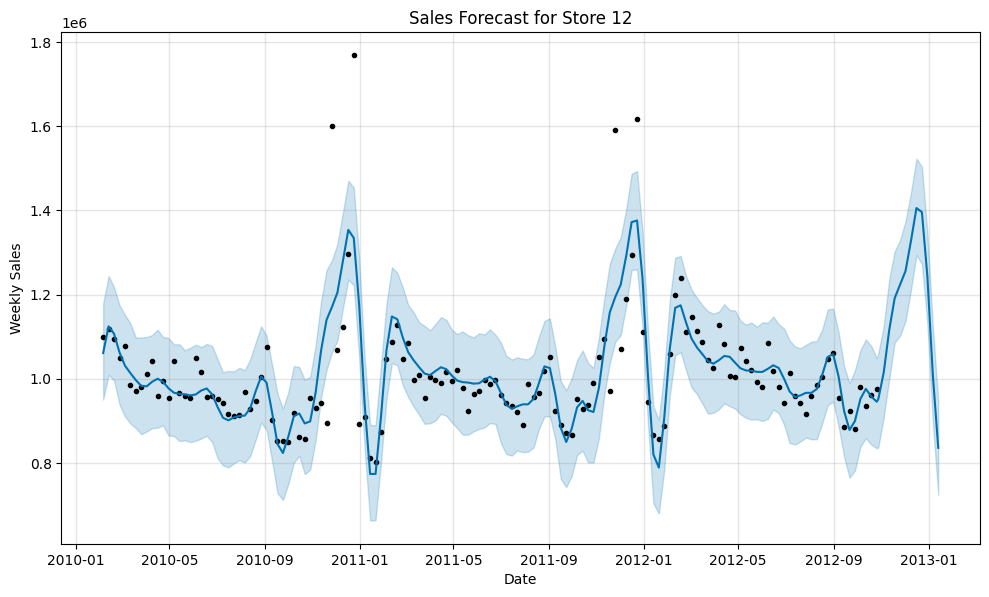

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/h7hikibx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/959fi958.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=50688', 'data', 'file=/tmp/tmpxis73i44/h7hikibx.json', 'init=/tmp/tmpxis73i44/959fi958.json', 'output', 'file=/tmp/tmpxis73i44/prophet_model2kbvto3x/prophet_model-20250502183019.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


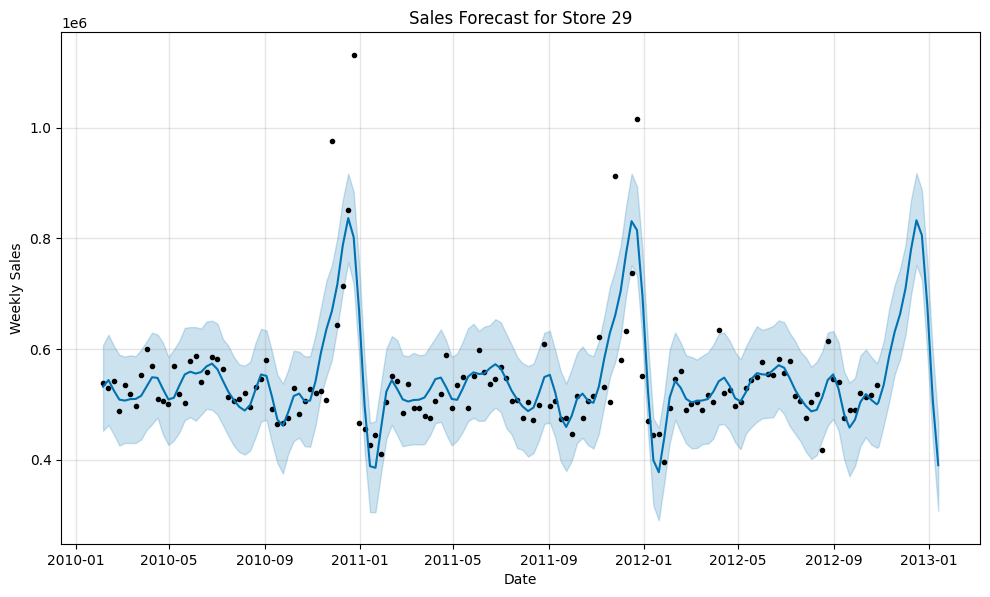

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/xtv2dkrq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/rmw6gcd0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=97686', 'data', 'file=/tmp/tmpxis73i44/xtv2dkrq.json', 'init=/tmp/tmpxis73i44/rmw6gcd0.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modeliul_x_lf/prophet_model-20250502183020.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


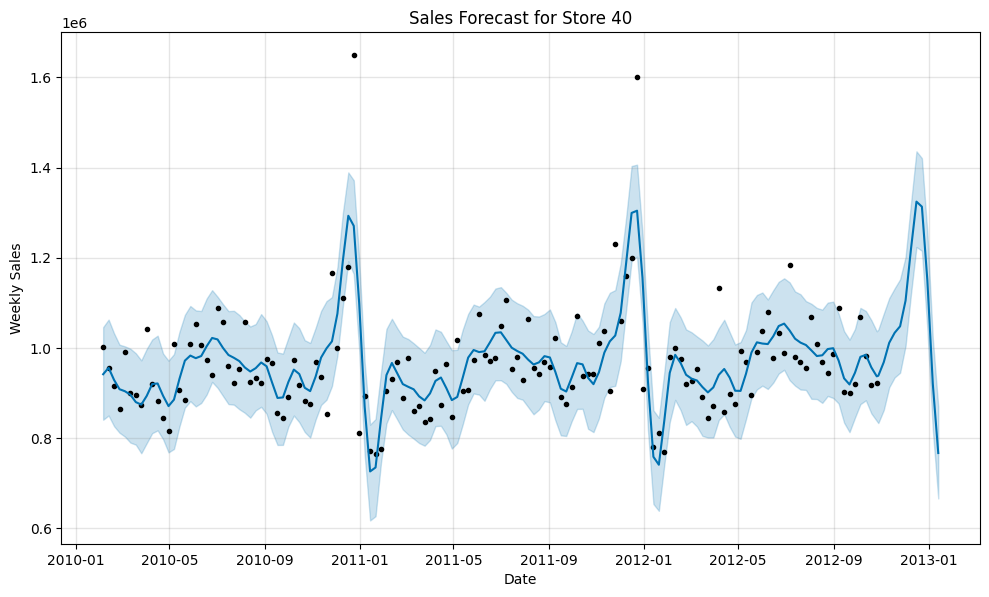

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/quhzfxzg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/v3o9mzje.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=93861', 'data', 'file=/tmp/tmpxis73i44/quhzfxzg.json', 'init=/tmp/tmpxis73i44/v3o9mzje.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelypas_zvu/prophet_model-20250502183020.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


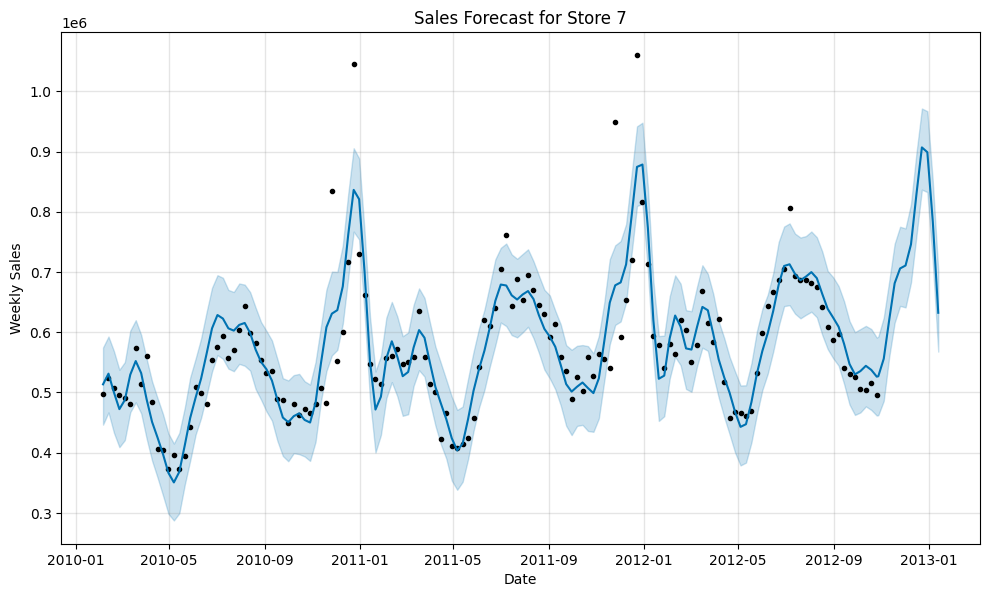

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/1murdqgm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxis73i44/v8vywxp_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=69477', 'data', 'file=/tmp/tmpxis73i44/1murdqgm.json', 'init=/tmp/tmpxis73i44/v8vywxp_.json', 'output', 'file=/tmp/tmpxis73i44/prophet_modelctmv8h8w/prophet_model-20250502183021.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:30:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:30:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


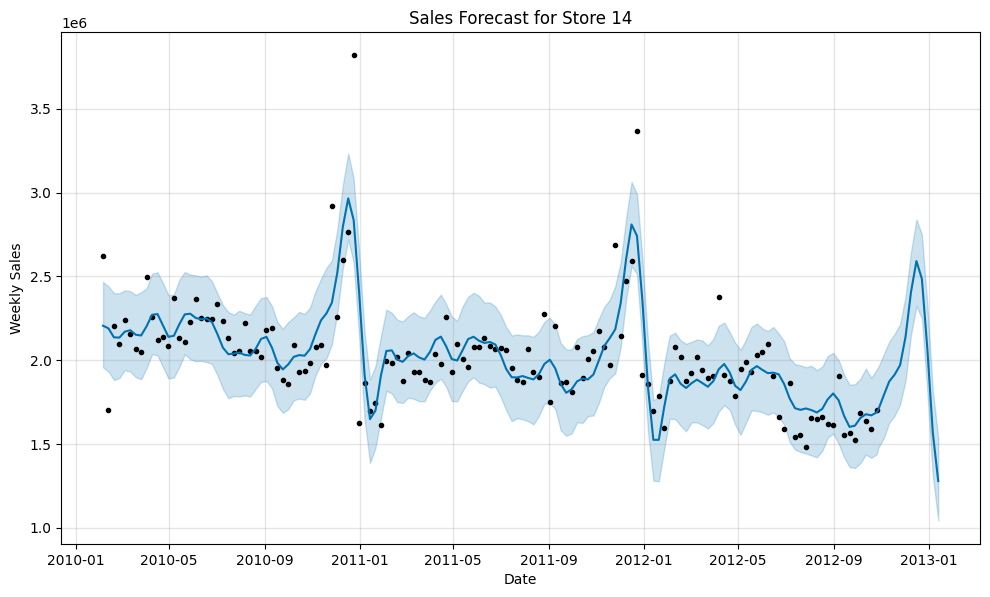

In [144]:

all_forecasts = []
for store_id in store_ids:
    # Filter data for this store
    store_data = df[df['Store'] == store_id][['Date', 'Weekly_Sales']].copy()
   # print(store_data['Date', 'Weekly_Sales'])
    # Rename columns for Prophet
    store_data.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'}, inplace=True)

    # Create Prophet model
    model = Prophet()

    # Fit model
    model.fit(store_data)

    # Make future dates (12 weeks ahead)
    future = model.make_future_dataframe(periods=12, freq='W')

    # Predict
    forecast = model.predict(future)

    # Select only date and predicted values
    future_sales = forecast[['ds', 'yhat']].tail(12)

    # Rename columns
    future_sales = future_sales.rename(columns={'ds': 'Date', 'yhat': 'Predicted_Weekly_Sales'})

    # Add store ID
    future_sales['Store'] = store_id

    # Save this store's forecast
    all_forecasts.append(future_sales)

    # Optional: plot
    model.plot(forecast)
    plt.title(f'Sales Forecast for Store {store_id}')
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales')
    plt.show()